<h1>Data preparation</h1>

<h2>0. Libraries</h2>

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import shap
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer,
    precision_recall_curve,
    average_precision_score,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier

In [39]:
!pip install shap

<h1>1. Import data</h1>

In [40]:
df_sirh = pd.read_csv("C:/Users/vtmnh/OneDrive/Tài liệu/openclassroom_formation IA/projet10_machine_learning/extrait_sirh.csv")
df_eval = pd.read_csv("C:/Users/vtmnh/OneDrive/Tài liệu/openclassroom_formation IA/projet10_machine_learning/extrait_eval.csv")
df_sondage = pd.read_csv("C:/Users/vtmnh/OneDrive/Tài liệu/openclassroom_formation IA/projet10_machine_learning/extrait_sondage.csv")


<h1>2. Verification data</h1>

In [41]:
def check_data(df):

    print("=" * 60)
    print("1. INFORMATIONS GÉNÉRALES")
    print("=" * 60)

    print(f"Nombre de lignes : {df.shape[0]:,}")
    print(f"Nombre de colonnes : {df.shape[1]:,}")
    print(f"Taille totale : {df.size:,} cellules")

    print("\nIndex :")
    print(f"  - Type : {type(df.index).__name__}")
    print(f"  - Unique : {df.index.is_unique}")

    print("\n" + "=" * 60)
    print("2. TYPES DE DONNÉES")
    print("=" * 60)

    print(df.dtypes)

    print("\nRépartition des types :")
    print(df.dtypes.value_counts())

    print("\n" + "=" * 60)
    print("3. VALEURS MANQUANTES")
    print("=" * 60)

    null_count = df.isnull().sum()
    null_pct = (null_count / len(df) * 100).round(2)

    missing = pd.DataFrame({
        "Nb_null": null_count,
        "%_null": null_pct
    })

    missing = missing[missing["Nb_null"] > 0]
    missing = missing.sort_values("%_null", ascending=False)

    if missing.empty:
        print("Aucune valeur manquante.")
    else:
        print(missing)

    print("\n" + "=" * 60)
    print("4. DOUBLONS")
    print("=" * 60)

    duplicate_count = df.duplicated().sum()
    duplicate_pct = duplicate_count / len(df) * 100

    print(f"Nombre de lignes dupliquées : {duplicate_count:,}")
    print(f"Pourcentage : {duplicate_pct:.2f}%")

    print("\n" + "=" * 60)
    print("5. COLONNES")
    print("=" * 60)

    columns_info = pd.DataFrame({
        "Type": df.dtypes,
        "Nb_unique": df.nunique(),
        "Nb_null": df.isnull().sum(),
        "%_null": (df.isnull().sum() / len(df) * 100).round(2)
    })

    print(columns_info)

    print("\n" + "=" * 60)
    print("6. STATISTIQUES NUMÉRIQUES")
    print("=" * 60)

    numeric_cols = df.select_dtypes(include=np.number).columns

    if len(numeric_cols) > 0:
        print(df[numeric_cols].describe().T)
    else:
        print("Aucune variable numérique.")

    print("\n" + "=" * 60)
    print("7. VARIABLES CATÉGORIELLES")
    print("=" * 60)

    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns

    if len(categorical_cols) > 0:
        categorical_info = pd.DataFrame({
            "Nb_unique": df[categorical_cols].nunique(),
            "Mode": [
                df[col].mode().iloc[0] if not df[col].mode().empty else np.nan
                for col in categorical_cols
            ]
        })

        print(categorical_info)
    else:
        print("Aucune variable catégorielle.")

In [42]:
print("CHECK TABLEAU SIRH")
check_data(df_sirh)

CHECK TABLEAU SIRH
1. INFORMATIONS GÉNÉRALES
Nombre de lignes : 1,470
Nombre de colonnes : 12
Taille totale : 17,640 cellules

Index :
  - Type : RangeIndex
  - Unique : True

2. TYPES DE DONNÉES
id_employee                        int64
age                                int64
genre                             object
revenu_mensuel                     int64
statut_marital                    object
departement                       object
poste                             object
nombre_experiences_precedentes     int64
nombre_heures_travailless          int64
annee_experience_totale            int64
annees_dans_l_entreprise           int64
annees_dans_le_poste_actuel        int64
dtype: object

Répartition des types :
int64     8
object    4
Name: count, dtype: int64

3. VALEURS MANQUANTES
Aucune valeur manquante.

4. DOUBLONS
Nombre de lignes dupliquées : 0
Pourcentage : 0.00%

5. COLONNES
                                  Type  Nb_unique  Nb_null  %_null
id_employee                   

In [43]:
print("CHECK TABLEAU EVALUATION")
check_data(df_eval)

CHECK TABLEAU EVALUATION
1. INFORMATIONS GÉNÉRALES
Nombre de lignes : 1,470
Nombre de colonnes : 10
Taille totale : 14,700 cellules

Index :
  - Type : RangeIndex
  - Unique : True

2. TYPES DE DONNÉES
satisfaction_employee_environnement           int64
note_evaluation_precedente                    int64
niveau_hierarchique_poste                     int64
satisfaction_employee_nature_travail          int64
satisfaction_employee_equipe                  int64
satisfaction_employee_equilibre_pro_perso     int64
eval_number                                  object
note_evaluation_actuelle                      int64
heure_supplementaires                        object
augementation_salaire_precedente             object
dtype: object

Répartition des types :
int64     7
object    3
Name: count, dtype: int64

3. VALEURS MANQUANTES
Aucune valeur manquante.

4. DOUBLONS
Nombre de lignes dupliquées : 0
Pourcentage : 0.00%

5. COLONNES
                                             Type  Nb_unique  N

In [44]:
print("CHECK TABLEAU SONDAGE")
check_data(df_sondage)

CHECK TABLEAU SONDAGE
1. INFORMATIONS GÉNÉRALES
Nombre de lignes : 1,470
Nombre de colonnes : 12
Taille totale : 17,640 cellules

Index :
  - Type : RangeIndex
  - Unique : True

2. TYPES DE DONNÉES
a_quitte_l_entreprise                  object
nombre_participation_pee                int64
nb_formations_suivies                   int64
nombre_employee_sous_responsabilite     int64
code_sondage                            int64
distance_domicile_travail               int64
niveau_education                        int64
domaine_etude                          object
ayant_enfants                          object
frequence_deplacement                  object
annees_depuis_la_derniere_promotion     int64
annes_sous_responsable_actuel           int64
dtype: object

Répartition des types :
int64     8
object    4
Name: count, dtype: int64

3. VALEURS MANQUANTES
Aucune valeur manquante.

4. DOUBLONS
Nombre de lignes dupliquées : 0
Pourcentage : 0.00%

5. COLONNES
                                  

<h1>3. Jointure</h1>

In [45]:
df_eval["id_employee"] = (
    df_eval["eval_number"]
    .str.replace("E_", "", regex=False)
    .astype(int)
)
df_eval[
    ["eval_number", "id_employee"]
].head()


,eval_number,id_employee
0,E_1,1
1,E_2,2
2,E_4,4
3,E_5,5
4,E_7,7


In [46]:
df_central = (
    df_sirh
    .merge(
        df_eval,
        on="id_employee",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        df_sondage,
        left_on="id_employee",
        right_on="code_sondage",
        how="inner",
        validate="one_to_one"
    )
)
display(df_central)

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,...,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,...,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,...,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,...,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,...,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,2061,36,M,2571,Marié(e),Consulting,Consultant,4,80,17,...,3,1,2061,23,2,Transformation Digitale,Y,Frequent,0,3
1466,2062,39,M,9991,Marié(e),Consulting,Manager,4,80,9,...,5,1,2062,6,1,Transformation Digitale,Y,Occasionnel,1,7
1467,2064,27,M,6142,Marié(e),Consulting,Tech Lead,1,80,6,...,0,1,2064,4,3,Infra & Cloud,Y,Occasionnel,0,3
1468,2065,49,M,5390,Marié(e),Commercial,Cadre Commercial,2,80,17,...,3,1,2065,2,3,Transformation Digitale,Y,Frequent,0,8


In [47]:
df_central.nunique().sort_values()

nombre_employee_sous_responsabilite             1
ayant_enfants                                   1
nombre_heures_travailless                       1
genre                                           2
heure_supplementaires                           2
note_evaluation_actuelle                        2
a_quitte_l_entreprise                           2
frequence_deplacement                           3
statut_marital                                  3
departement                                     3
satisfaction_employee_equilibre_pro_perso       4
satisfaction_employee_nature_travail            4
note_evaluation_precedente                      4
satisfaction_employee_equipe                    4
satisfaction_employee_environnement             4
nombre_participation_pee                        4
niveau_hierarchique_poste                       5
niveau_education                                5
domaine_etude                                   6
nb_formations_suivies                           7


<h1>4. Statistiques descriptives</h1>

<h2>4.1 Nombre d'employés ont quitté l'entreprise</h2>

a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64


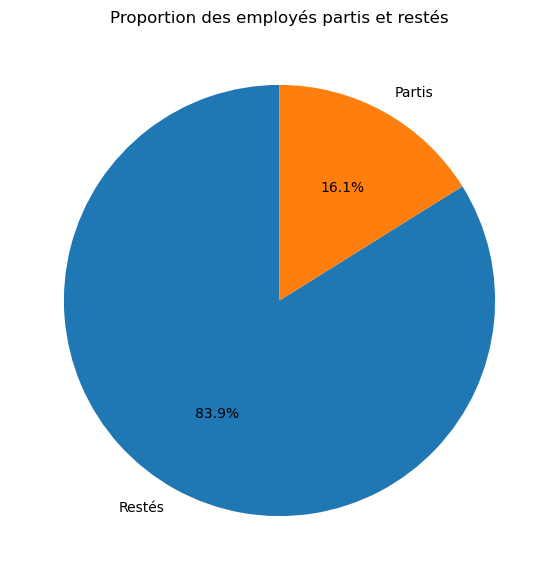

In [48]:
repartition=df_central["a_quitte_l_entreprise"].value_counts()
print(repartition)
df_central["a_quitte_l_entreprise"].value_counts(normalize=True) * 100
labels = [
    "Partis" if valeur == "Oui" else "Restés"
    for valeur in repartition.index
]

plt.figure(figsize=(7, 7))

plt.pie(
    repartition,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proportion des employés partis et restés")

plt.show()

<h2>4.2 Profil démographique et départ</h2>

In [49]:
df_quitte = df_central[
    df_central["a_quitte_l_entreprise"] == "Oui"
]


<h3>4.2.1 Age</h3>

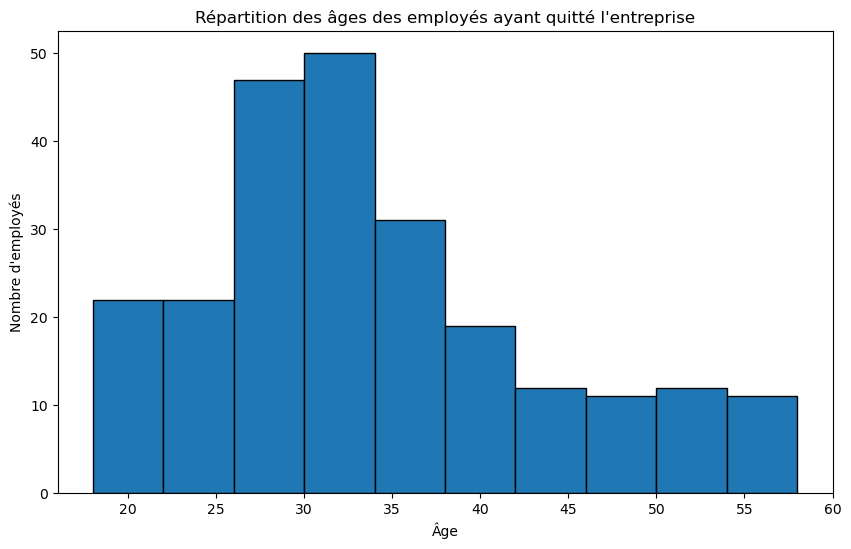

In [50]:
df_quitte["age"].mean()
plt.figure(figsize=(10, 6))

plt.hist(
    df_quitte["age"],
    bins=10,
    edgecolor="black"
)

plt.title("Répartition des âges des employés ayant quitté l'entreprise")
plt.xlabel("Âge")
plt.ylabel("Nombre d'employés")

plt.show()

<h3>4.2.2 Genre</h3>

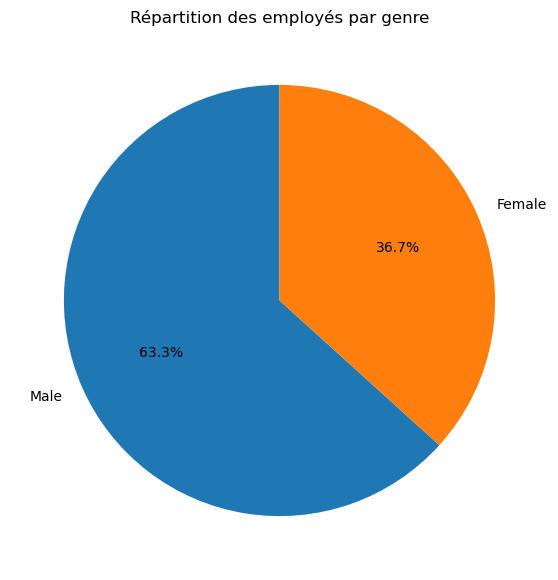

In [51]:
repartition_genre = df_quitte["genre"].value_counts()

# Créer le pie chart
plt.figure(figsize=(7, 7))
labels = [
    "Female" if valeur == "F" else "Male"
    for valeur in repartition_genre.index
]
plt.pie(
    repartition_genre,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des employés par genre")
plt.show()

<h3>4.2.3 Statut marital</h3>

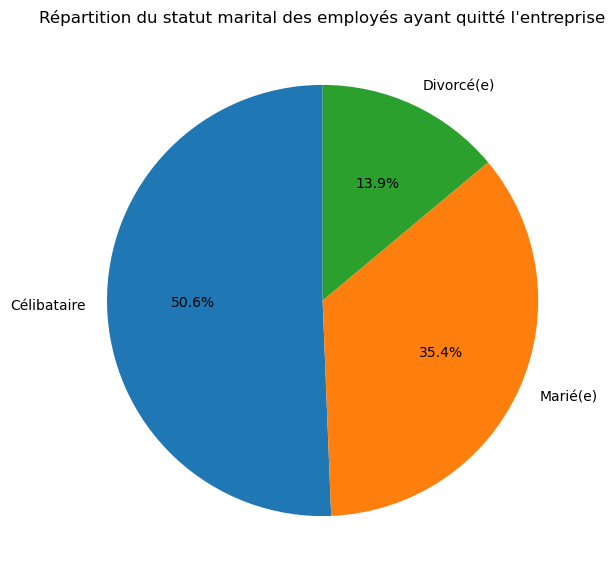

In [52]:
repartition = df_quitte["statut_marital"].value_counts()
plt.figure(figsize=(7, 7))

plt.pie(
    repartition,
    labels=repartition.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition du statut marital des employés ayant quitté l'entreprise")
plt.show()

<h3>4.2.4 Ayant enfant</h3>

In [53]:
df_quitte["ayant_enfants"].value_counts()

ayant_enfants
Y    237
Name: count, dtype: int64

<h3>4.2.5 Combinasion</h3>

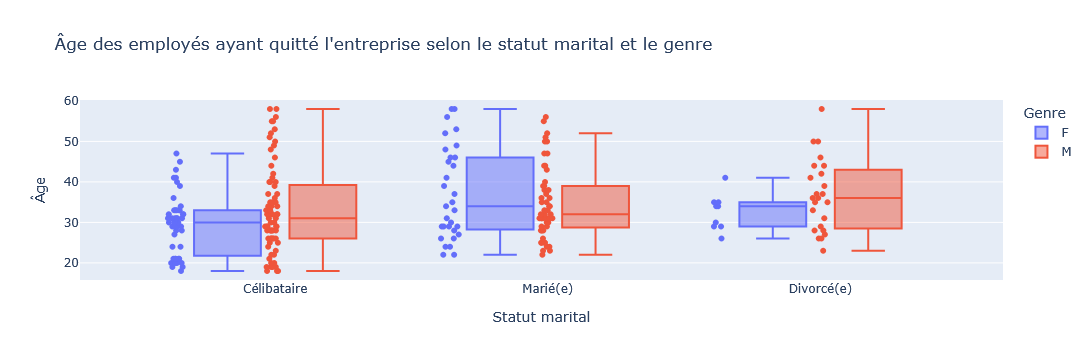

In [54]:
fig = px.box(
    df_quitte,
    x="statut_marital",
    y="age",
    color="genre",
    points="all",
    hover_data=[
        "statut_marital",
        "genre",
        "age"
    ],
    title="Âge des employés ayant quitté l'entreprise selon le statut marital et le genre"
)

fig.update_layout(
    xaxis_title="Statut marital",
    yaxis_title="Âge",
    legend_title="Genre"
)

fig.show()

<h2>4.3 Salaire</h2>

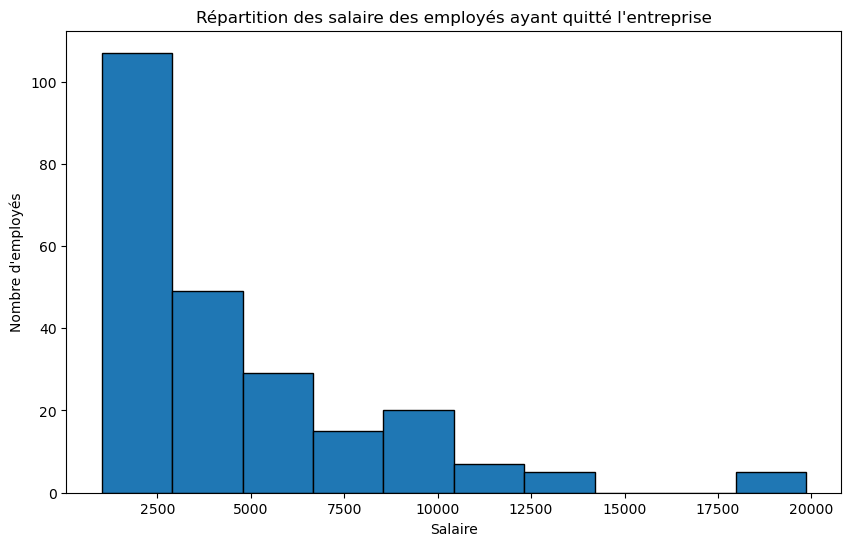

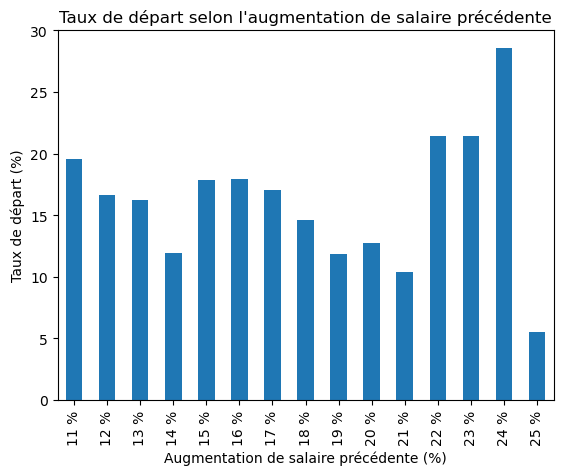

In [55]:
df_quitte["revenu_mensuel"].mean()
plt.figure(figsize=(10, 6))

plt.hist(
    df_quitte["revenu_mensuel"],
    bins=10,
    edgecolor="black"
)

plt.title("Répartition des salaire des employés ayant quitté l'entreprise")
plt.xlabel("Salaire")
plt.ylabel("Nombre d'employés")

plt.show()
taux_depart = (
    df_central.groupby("augementation_salaire_precedente")["a_quitte_l_entreprise"]
    .apply(lambda x: (x == "Oui").mean() * 100)
)

taux_depart.plot(kind="bar")

plt.title("Taux de départ selon l'augmentation de salaire précédente")
plt.xlabel("Augmentation de salaire précédente (%)")
plt.ylabel("Taux de départ (%)")
plt.show()

<h3>4.4 Ancienneté</h3>

In [56]:
df_quitte["annees_dans_l_entreprise"].mean()

np.float64(5.1308016877637135)

<h1>5. Netoyage data</h1>

<h2>5.1 Suprime colonnes unutiles pour analyse</h2>

In [57]:
# Supprime les colonnes avec une seule valeur et non utiles pour model
df_central = df_central.drop(
    columns=[
        "id_employee",
        "code_sondage",
        "eval_number",
    ]
)
df_sans_unique_valeur = df_central.copy()
df_sans_unique_valeur = df_sans_unique_valeur.drop(

    columns=[
        "ayant_enfants",
        "nombre_employee_sous_responsabilite",
        "nombre_heures_travailless"
    ]
)
df_sans_unique_valeur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 28 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   age                                        1470 non-null   int64 
 1   genre                                      1470 non-null   object
 2   revenu_mensuel                             1470 non-null   int64 
 3   statut_marital                             1470 non-null   object
 4   departement                                1470 non-null   object
 5   poste                                      1470 non-null   object
 6   nombre_experiences_precedentes             1470 non-null   int64 
 7   annee_experience_totale                    1470 non-null   int64 
 8   annees_dans_l_entreprise                   1470 non-null   int64 
 9   annees_dans_le_poste_actuel                1470 non-null   int64 
 10  satisfaction_employee_environnement 

<h2>5.2 Features numeriques</h2>

In [58]:
# mapping features binaire et ordinaire
df_sans_unique_valeur["genre"] = df_sans_unique_valeur["genre"].map({
    "F": 0,
    "M": 1
})
df_sans_unique_valeur["heure_supplementaires"] = df_sans_unique_valeur["heure_supplementaires"].map({
    "Oui": 1,
    "Non": 0
})
df_sans_unique_valeur["frequence_deplacement"] = df_sans_unique_valeur["frequence_deplacement"].map({
    "Aucun": 0,
    "Occasionnel": 1,
    "Frequent": 2
})
print(df_sans_unique_valeur[["genre","heure_supplementaires","frequence_deplacement"]])

      genre  heure_supplementaires  frequence_deplacement
0         0                      1                      1
1         1                      0                      2
2         1                      1                      1
3         0                      1                      2
4         1                      0                      1
...     ...                    ...                    ...
1465      1                      0                      2
1466      1                      0                      1
1467      1                      1                      1
1468      1                      0                      2
1469      1                      0                      1

[1470 rows x 3 columns]


In [59]:
# convertir type object en numerique
df_sans_unique_valeur["augementation_salaire_precedente"] = (
    df_sans_unique_valeur["augementation_salaire_precedente"]
        .str.replace("%", "", regex=False)
        .str.strip()
        .astype(int)
)
df_sans_unique_valeur["augementation_salaire_precedente"].unique()

array([11, 23, 15, 12, 13, 20, 22, 21, 17, 14, 16, 18, 19, 24, 25])

<h1>6. Creation features</h1>

In [78]:
df_feature_neuf = df_sans_unique_valeur.copy()
# score satisfaction
df_feature_neuf["score_satisfaction_global"] = round((
    df_feature_neuf["satisfaction_employee_environnement"]
    + df_feature_neuf["satisfaction_employee_nature_travail"]
    + df_feature_neuf["satisfaction_employee_equipe"]
    + df_feature_neuf["satisfaction_employee_equilibre_pro_perso"]
)/4,2)
# taux promotion
df_feature_neuf["taux_promotion"] = round((
    df_feature_neuf["annees_depuis_la_derniere_promotion"]
    /
    (df_feature_neuf["annees_dans_l_entreprise"] + 1)
),2)
# poste heure supp
df_feature_neuf["poste_heures_supp"] = (
    df_feature_neuf["poste"].astype(str)
    + "_"
    +
    df_feature_neuf["heure_supplementaires"].astype(str)
)
df_feature_neuf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        1470 non-null   int64  
 1   genre                                      1470 non-null   int64  
 2   revenu_mensuel                             1470 non-null   int64  
 3   statut_marital                             1470 non-null   object 
 4   departement                                1470 non-null   object 
 5   poste                                      1470 non-null   object 
 6   nombre_experiences_precedentes             1470 non-null   int64  
 7   annee_experience_totale                    1470 non-null   int64  
 8   annees_dans_l_entreprise                   1470 non-null   int64  
 9   annees_dans_le_poste_actuel                1470 non-null   int64  
 10  satisfaction_employee_en

<h1>7. Feature sets</h1>

In [126]:
df_feature_important= df_feature_neuf.copy()
df_feature_important=df_feature_important    [
    [
        "revenu_mensuel",
        "annee_experience_totale",
        "annees_dans_l_entreprise",
        "age",
        "niveau_hierarchique_poste",
        "nombre_participation_pee",
        "poste_heures_supp",
        "statut_marital",
        "score_satisfaction_global",
        "satisfaction_employee_equilibre_pro_perso",
        "departement",
        "frequence_deplacement",
        "poste",
        "a_quitte_l_entreprise"
    ]]
df_feature_neuf_sans_revenu = df_feature_neuf.copy()
df_feature_neuf_sans_revenu = df_feature_neuf_sans_revenu.drop(columns=["revenu_mensuel"])

feature_sets = {
    "Original": df_sans_unique_valeur,
    "Feature Engineering": df_feature_neuf,
    "Feature Engineering Sans Revenu": df_feature_neuf_sans_revenu,
    "Important Features": df_feature_important
}


<h1>Preprocess</h1>

In [112]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
# type de columnes
def func_numeric_features(df, binary_features):
    numeric_features = (
        df.select_dtypes(include=["int64", "float64"])
        .columns
        .difference(binary_features)
    )
    return numeric_features

def func_categorical_features(df):
    categorical_features = df.select_dtypes(
        include=["object"]
    ).columns
    return categorical_features

#preprocessing
def func_preprocess(num_method, numeric_features, cat_method, categorical_features):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                num_method,
                numeric_features
            ),
            (
                "cat",
                cat_method,
                categorical_features
            )
        ]
    )
    return preprocessor

#pipeline
def func_pipeline   (
    model,
    X,
    binary_features,
    num_method,
    cat_method
):
    num_features = func_numeric_features(
        X,
        binary_features
    )

    cat_features = func_categorical_features(X)

    preprocessor = func_preprocess(
        num_method,
        num_features,
        cat_method,
        cat_features
    )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )
    return pipeline

def func_model_pipeline(
    df,
    target,
    model,
    binary_features,
    num_method,
    cat_method
):
    # X / y
    
    X = df.drop(columns=[target])
    y = df[target]

    # Train / test stratifié
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # Construction du pipeline
    model_pipeline = func_pipeline(
        model,
        X_train,
        binary_features,
        num_method,
        cat_method
    )

    return (
        model_pipeline,
        X_test,
        y_test,
        X_train,
        y_train
    )

<h1>Scoring</h1>

In [113]:
def scoring_model(
    model_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    feature_name
):
    
    # Predictions
    y_train_pred = model_pipeline.predict(X_train)
    y_test_pred = model_pipeline.predict(X_test)

    # Classification reports
    train_report = classification_report(
        y_train,
        y_train_pred,
        output_dict=True,
        zero_division=0
    )

    test_report = classification_report(
        y_test,
        y_test_pred,
        output_dict=True,
        zero_division=0
    )

    return {
        "Feature Set": feature_name,

        # =====================
        # TRAIN
        # =====================
        "Train_Accuracy": accuracy_score(
            y_train, y_train_pred
        ),

        "Train_Precision": precision_score(
            y_train,
            y_train_pred,
            pos_label="Oui",
            zero_division=0
        ),

        "Train_Recall": recall_score(
            y_train,
            y_train_pred,
            pos_label="Oui",
            zero_division=0
        ),

        "Train_F1": f1_score(
            y_train,
            y_train_pred,
            pos_label="Oui",
            zero_division=0
        ),

        # =====================
        # TEST
        # =====================
        "Test_Accuracy": accuracy_score(
            y_test, y_test_pred
        ),

        "Test_Precision": precision_score(
            y_test,
            y_test_pred,
            pos_label="Oui",
            zero_division=0
        ),

        "Test_Recall": recall_score(
            y_test,
            y_test_pred,
            pos_label="Oui",
            zero_division=0
        ),

        "Test_F1": f1_score(
            y_test,
            y_test_pred,
            pos_label="Oui",
            zero_division=0
        ),

        # =====================
        # CLASSIFICATION REPORT
        # =====================
        "Train_F1_Oui": train_report.get(
            "Oui", {}
        ).get("f1-score", 0),

        "Test_F1_Oui": test_report.get(
            "Oui", {}
        ).get("f1-score", 0),

        "Train_Recall_Oui": train_report.get(
            "Oui", {}
        ).get("recall", 0),

        "Test_Recall_Oui": test_report.get(
            "Oui", {}
        ).get("recall", 0),
        
        "Train_F1_Non": train_report.get(
            "Non", {}
        ).get("f1-score", 1),

        "Test_F1_Non": test_report.get(
            "Non", {}
        ).get("f1-score", 1),

        "Train_Recall_Non": train_report.get(
            "Non", {}
        ).get("recall", 1),

        "Test_Recall_Non": test_report.get(
            "Non", {}
        ).get("recall", 1),
    }

In [114]:
def func_evaluate_model(
    model,
    feature_sets,
    target,
    binary_features,
    num_method,
    cat_method
):
    results = []

    for feature_name, df in feature_sets.items():

        model_pipeline, X_test, y_test, X_train, y_train = func_model_pipeline(
                    df,
                    target,
                    model,
                    binary_features,
                    num_method,
                    cat_method
                )
        # Entraînement
        model_pipeline.fit(X_train, y_train)

        # Scoring
        result = scoring_model(
            model_pipeline,
            X_train,
            y_train,
            X_test,
            y_test,
            feature_name
        )

        results.append(result)

    return pd.DataFrame(results)

<h1>Plot Precision-Recall Curve</h1>

In [115]:
def plot_precision_recall_curve(model, X_test, y_test, model_name, pos_label="Oui"):
    # Identifier la colonne correspondant à la classe positive
    pos_index = list(model.classes_).index(pos_label)

    y_proba_positive = model.predict_proba(X_test)[:, pos_index]
    
    # Calcul Precision, Recall et seuils
    precision, recall, thresholds = precision_recall_curve(
        y_test,
        y_proba_positive,
        pos_label=pos_label
    )

    # Average Precision
    average_precision = average_precision_score(
        y_test,
        y_proba_positive,
        pos_label=pos_label
    )

    # Tracé
    plt.figure(figsize=(8, 6))

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP = {average_precision:.3f})"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {model_name}")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.show()

    return average_precision

<h1>Permutation importance</h1>

In [116]:
def func_get_permutation_importance(model, X_test, y_test):

    recall_oui = make_scorer(
        recall_score,
        pos_label="Oui",
        zero_division=0
    )

    result = permutation_importance(
        model,
        X_test,
        y_test,
        scoring=recall_oui,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    permutation_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Permutation Importance": result.importances_mean
    })

    permutation_df["Permutation Rank"] = (
        permutation_df["Permutation Importance"]
        .rank(method="min", ascending=False)
        .astype(int)
    )
    permutation_df = permutation_df.sort_values(
        "Permutation Rank"
    ).reset_index(drop=True)

    return permutation_df

In [117]:
def func_plot_permutation_importance(importance, feature_name):
    importance = importance.set_index("Feature")
    importance.plot(kind="bar", figsize=(10, 6))
    plt.title(f"Permutation Importance - {feature_name}")
    plt.ylabel("Mean decrease in Recall (Oui)")
    plt.xlabel("Features")
    plt.tight_layout()
    plt.show()

<h1>Shap</h1>

In [118]:
def func_shap_importance(
    model_pipeline,
    is_linear,
    X_test,
    positive_class="Oui",
    pipeline=True
):

    # =====================================================
    # Preprocessing
    # =====================================================

    

    preprocessor = model_pipeline.steps[0][1]
    estimator = model_pipeline.steps[-1][1]

    X_transformed = preprocessor.transform(
        X_test
    )

    transformed_feature_names = (
        preprocessor
        .get_feature_names_out()
    )
    
    # =====================================================
    # SHAP Explainer
    # =====================================================

    if is_linear:

        explainer = shap.LinearExplainer(
            estimator,
            X_transformed
        )

    else:

        explainer = shap.TreeExplainer(
            estimator
        )

    shap_values = explainer.shap_values(
        X_transformed
    )
    # =====================================================
    # Positive class
    # =====================================================

    if hasattr(estimator, "classes_"):

        classes = list(estimator.classes_)
    
        if positive_class in classes:
            positive_index = classes.index(positive_class)
        else:
            raise ValueError(
                f"positive_class={positive_class!r} "
                f"not found in estimator.classes_={classes}"
            )
    
    else:
        positive_index = None

    # =====================================================
    # Gérer différentes versions SHAP
    # =====================================================

    if isinstance(shap_values, list):

        if positive_index is None:
            raise ValueError(
                "Impossible de déterminer la classe positive pour sélectionner les valeurs SHAP."
            )
    
        if positive_index >= len(shap_values):
            raise ValueError(
                f"positive_index={positive_index} est invalide. "
                f"Le nombre de classes SHAP disponibles est "
                f"{len(shap_values)}."
            )
    
        shap_values_positive = (
            shap_values[positive_index]
        )


    elif isinstance(shap_values, np.ndarray):
    
        if shap_values.ndim == 3:
    
            if positive_index is None:
                raise ValueError(
                    "Impossible de déterminer la classe positive "
                    "pour sélectionner les valeurs SHAP."
                )
    
            if positive_index >= shap_values.shape[2]:
                raise ValueError(
                    f"positive_index={positive_index} est invalide. "
                    f"Le nombre de classes SHAP disponibles est "
                    f"{shap_values.shape[2]}."
                )
    
            shap_values_positive = (
                shap_values[
                    :,
                    :,
                    positive_index
                ]
            )

        elif shap_values.ndim == 2:
    
            shap_values_positive = shap_values
    
        else:
    
            raise ValueError(
                "Format SHAP non reconnu : "
                f"shape={shap_values.shape}."
            )


    else:
    
        raise ValueError(
            "Format SHAP non reconnu : "
            f"type={type(shap_values)}."
        )
    # =====================================================
    # Mapping transformed feature -> original feature
    # =====================================================

    original_feature_names = [
        get_original_feature(
            name,
            X_test
        )
        for name in transformed_feature_names
    ]

    # =====================================================
    # Aggregate SHAP values by original feature
    # =====================================================

    original_features_unique = list(
        dict.fromkeys(
            original_feature_names
        )
    )

    shap_values_original = np.zeros(
        (
            shap_values_positive.shape[0],
            len(original_features_unique)
        )
    )

    for i, original_feature in enumerate(
        original_features_unique
    ):

        indices = [
            j
            for j, feature in enumerate(
                original_feature_names
            )
            if feature == original_feature
        ]

        # Agrégation des SHAP values des features transformées vers les features originales
        shap_values_original[:, i] = (
            shap_values_positive[
                :,
                indices
            ].sum(axis=1)
        )

    # =====================================================
    # Mean absolute SHAP
    # =====================================================

    mean_abs_shap = np.abs(
        shap_values_original
    ).mean(axis=0)

    # =====================================================
    # Tableau importance
    # =====================================================

    shap_df = pd.DataFrame({

        "Feature": original_features_unique,

        "Mean |SHAP|": mean_abs_shap

    })

    # =====================================================
    # SHAP Rank
    # =====================================================

    shap_df["SHAP Rank"] = (
        shap_df["Mean |SHAP|"]
        .rank(
            method="min",
            ascending=False
        )
        .astype(int)
    )

    shap_df = (
        shap_df
        .sort_values(
            "SHAP Rank"
        )
        .reset_index(drop=True)
    )

    # =====================================================
    # Return
    # =====================================================

    return (
        shap_df,
        shap_values_original,
        np.array(original_features_unique),
        X_test,
        positive_index,
        explainer
    )

In [119]:
def func_plot_shap(
    shap_values_original,
    X_test,
    feature_names
):

    X_original = X_test[
        list(feature_names)
    ]

    shap.summary_plot(
        shap_values_original,
        X_original,
        feature_names=feature_names
    )

<h1> Shap plots scatter</h1>

In [120]:
def func_shap_scatter(
    shap_values_original,
    original_features,
    X_test,
    feature_name,
    max_display=20,
    figsize=(10, 7),
    
):
    """
    Scatter plot des SHAP values agrégées
    au niveau des features originales.
    """

    shap_df = pd.DataFrame(
        shap_values_original,
        columns=original_features,
        index=X_test.index
    )

    # Importance
    importance = (
        shap_df.abs()
        .mean()
        .sort_values(ascending=False)
    )

    selected_features = (
        importance
        .head(max_display)
        .index
        .tolist()
    )

    # Ordre pour le graphique
    selected_features = selected_features[::-1]

    fig, ax = plt.subplots(figsize=figsize)

    for y, feature in enumerate(selected_features):

        values = shap_df[feature]

        # jitter vertical
        y_values = (
            np.ones(len(values)) * y
            + np.random.normal(
                0,
                0.08,
                len(values)
            )
        )

        ax.scatter(
            values,
            y_values,
            alpha=0.5,
            s=20
        )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_yticks(
        range(len(selected_features))
    )

    ax.set_yticklabels(
        selected_features
    )

    ax.set_xlabel("SHAP value")
    ax.set_ylabel("Feature")

    ax.set_title(
        f"SHAP values - {feature_name}"
    )
    plt.tight_layout()
    plt.show()


<h1>Features importants: Combine permutation importance et Shap</h1>

In [121]:
def get_original_feature(name, X_test):

    # Remove transformer prefix
    if name.startswith("num__"):
        return name.replace("num__", "", 1)

    if name.startswith("cat__"):
        transformed_name = name.replace("cat__", "", 1)

        # Chercher la colonne originale la plus longue
        # qui correspond au début du nom transformé
        matching_columns = [
            col
            for col in X_test.columns
            if (
                transformed_name == col
                or transformed_name.startswith(col + "_")
            )
        ]

        if matching_columns:
            # Prendre la colonne la plus longue
            return max(
                matching_columns,
                key=len
            )

        return transformed_name

    return name

In [122]:
def func_tableau_features_importants(
    shap_df,
    permutation_df
):

    # =====================================================
    # Merge
    # =====================================================

    df = pd.merge(

        permutation_df[
            [
                "Feature",
                "Permutation Rank"
            ]
        ],

        shap_df[
            [
                "Feature",
                "SHAP Rank"
            ]
        ],

        on="Feature",

        how="inner"
    )

    # =====================================================
    # Combined Rank
    # =====================================================

    df["Combined Rank"] = (
        df["Permutation Rank"]
        + df["SHAP Rank"]
    )

    # =====================================================
    # Sort
    # =====================================================

    df = (
        df[
            [
                "Feature",
                "Permutation Rank",
                "SHAP Rank",
                "Combined Rank"
            ]
        ]
        .sort_values(
            "Combined Rank"
        )
        .reset_index(drop=True)
    )

    return df

<h1>Shap Waterfall</h1>

In [143]:
def func_shap_waterfall(
    shap_values_original,
    original_features,
    X_test,
    explainer,
    model_pipeline,
    positive_index=None,
    observation_index=0,
    max_display=13,
    figsize=(12, 8),
    df=None
):

    # =====================================================
    # Validation
    # =====================================================

    if observation_index < 0 or observation_index >= len(X_test):
        raise IndexError(
            f"observation_index={observation_index} "
            f"est hors limites. "
            f"X_test contient {len(X_test)} observations "
            f"(indices positionnels 0 à {len(X_test)-1})."
        )

    if max_display <= 0:
        raise ValueError(
            "max_display doit être supérieur à 0."
        )

    if max_display > len(original_features):
        raise ValueError(
            f"max_display ({max_display}) ne peut pas être supérieur "
            f"au nombre de features ({len(original_features)})."
        )

    # =====================================================
    # SHAP values de l'observation
    # =====================================================

    shap_values_obs = (
        shap_values_original[
            observation_index
        ]
    )

    # =====================================================
    # Valeurs de l'observation
    # =====================================================

    X_obs = X_test.iloc[
        [observation_index]
    ]
    # =====================================================
    # Infos de l'observation
    # =====================================================
    
    original_index = X_test.index[observation_index]
    employee_info = None

    if df is not None:
        employee_info = df.loc[original_index]
    
    # =====================================================
    # Preprocessing
    # =====================================================

    preprocessor = model_pipeline.steps[0][1]

    estimator = model_pipeline.steps[-1][1]

    X_obs_transformed = preprocessor.transform(
        X_obs
    )

    # =====================================================
    # Prediction réelle du modèle
    # =====================================================

    prediction_class = estimator.predict(
        X_obs_transformed
    )[0]

    # =====================================================
    # Prediction probability
    # =====================================================

    prediction_proba = None
    positive_probability = None

    if hasattr(
        estimator,
        "predict_proba"
    ):

        prediction_proba = (
            estimator
            .predict_proba(
                X_obs_transformed
            )[0]
        )

        if positive_index is not None:

            positive_probability = (
                prediction_proba[
                    positive_index
                ]
            )

    # =====================================================
    # Trier selon |SHAP|
    # =====================================================

    order_all = np.argsort(
        np.abs(
            shap_values_obs
        )
    )[::-1]

    top_order = order_all[
        :max_display
    ]

    other_order = order_all[
        max_display:
    ]

    # Inverser pour l'affichage waterfall

    order = top_order[::-1]

    features = [
        original_features[i]
        for i in order
    ]

    values = [
        shap_values_obs[i]
        for i in order
    ]

    # =====================================================
    # Autres features
    # =====================================================

    other_value = np.sum(
        shap_values_obs[
            other_order
        ]
    )

    # =====================================================
    # Valeur de base
    # =====================================================

    expected_value = (
        explainer.expected_value
    )

    if np.ndim(
        expected_value
    ) == 0:

        base_value = (
            expected_value
        )

    else:

        if positive_index is None:

            raise ValueError(
                "positive_index doit être fourni "
                "lorsque explainer.expected_value "
                "contient plusieurs valeurs."
            )

        base_value = (
            expected_value[
                positive_index
            ]
        )

    # =====================================================
    # SHAP final output
    # =====================================================

    shap_output = (
        base_value
        + np.sum(
            shap_values_obs
        )
    )

    # =====================================================
    # Vérification du calcul SHAP
    # =====================================================

    shap_reconstruction_error = None

    try:

        shap_model_output = (
            explainer.expected_value
            + np.sum(
                shap_values_obs
            )
        )

        if np.ndim(
            shap_model_output
        ) == 0:

            shap_reconstruction_error = (
                float(
                    shap_model_output
                )
                - float(
                    shap_output
                )
            )

    except Exception:

        shap_reconstruction_error = None

    # =====================================================
    # Création du graphique
    # =====================================================

    fig, ax = plt.subplots(
        figsize=figsize
    )

    cumulative = (
        base_value
    )

    # =====================================================
    # Features principales
    # =====================================================

    for feature, shap_value in zip(
        features,
        values
    ):

        color = (
            "blue"
            if shap_value >= 0
            else "red"
        )

        ax.barh(
            feature,
            shap_value,
            left=cumulative,
            color=color,
            alpha=0.8
        )

        cumulative += (
            shap_value
        )

    # =====================================================
    # Other features
    # =====================================================

    if len(
        other_order
    ) > 0:

        color = (
            "red"
            if other_value >= 0
            else "blue"
        )

        ax.barh(
            "Other features",
            other_value,
            left=cumulative,
            color=color,
            alpha=0.8
        )

        cumulative += (
            other_value
        )

    # =====================================================
    # Taille
    # =====================================================
    xmin = min(
        base_value,
        shap_output,
        ax.get_xlim()[0]
    )
    
    xmax = max(
        base_value,
        shap_output,
        ax.get_xlim()[1]
    )
    
    margin = 0.10 * (xmax - xmin)
    
    ax.set_xlim(
        xmin - margin,
        xmax + margin
    )
    
    # =====================================================
    # Baseline
    # =====================================================
    
    ax.axvline(
        base_value,
        linestyle="--",
        linewidth=1
    )
    
    # =====================================================
    # SHAP final output
    # =====================================================
    
    ax.axvline(
        shap_output,
        linestyle=":",
        linewidth=1.5
    )
    
    # =====================================================
    # Labels des lignes verticales
    # =====================================================
    
    ax.text(
        base_value,
        0.98,
        f"Base = {base_value:.4f}",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=9
    )
    
    ax.text(
        shap_output,
        0.90,
        f"SHAP = {shap_output:.4f}",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=9
    )
    # =====================================================
    # Labels
    # =====================================================

    ax.set_xlabel(
        "Model output"
    )

    ax.set_title(
        f"SHAP Waterfall - "
        f"Observation {observation_index}"
    )

    # =====================================================
    # Prediction information
    # =====================================================

    prediction_text = (
        f"Prediction : {prediction_class}"
    )

    if positive_probability is not None:

        prediction_text += (
            f"\nP({prediction_class}) : "
            f"{prediction_proba[
                list(estimator.classes_)
                .index(prediction_class)
            ]:.4f}"
        )

        if positive_index is not None:

            prediction_text += (
                f"\nP(positive) : "
                f"{positive_probability:.4f}"
            )

    prediction_text += (
        f"\n\nBase value : "
        f"{base_value:.4f}"
        f"\nSHAP output : "
        f"{shap_output:.4f}"
    )

    ax.text(
        0.98,
        0.02,
        prediction_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        bbox=dict(
            boxstyle="round",
            alpha=0.15
        )
    )

    plt.tight_layout()
    plt.show()

    # =====================================================
    # Résultats SHAP
    # =====================================================

    result = pd.DataFrame({

        "Feature": features,

        "SHAP value": values

    })

    if len(
        other_order
    ) > 0:

        result = pd.concat(
            [
                result,

                pd.DataFrame({
                    "Feature": [
                        "Other features"
                    ],

                    "SHAP value": [
                        other_value
                    ]
                })
            ],

            ignore_index=True
        )

    # =====================================================
    # Informations prediction
    # =====================================================

    prediction_info = {

        "observation_index":
            observation_index,
        
        "original_index": 
            original_index,

        "employee_info": 
            employee_info,
        
        "predicted_class":
            prediction_class,

        "positive_probability":
            positive_probability,

        "base_value":
            base_value,

        "shap_output":
            shap_output,

        "shap_reconstruction_error":
            shap_reconstruction_error
    }

    return (
        result,
        prediction_info
    )

<h1>Dummy Model</h1>

In [124]:
# build pipeline logistic
binary_features = [
    "genre",
    "heure_supplementaires"
]

target = "a_quitte_l_entreprise"

num_method = StandardScaler()

cat_method = OneHotEncoder(
    handle_unknown="ignore"
)

model_dummy= DummyClassifier(
    strategy="most_frequent"
)


# evaluate model
result_dummy = func_evaluate_model(
    model_dummy,
    feature_sets,
    target,
    binary_features,
    num_method,
    cat_method
)

print(result_dummy)

                       Feature Set  Train_Accuracy  Train_Precision  \
0                         Original        0.838435              0.0   
1              Feature Engineering        0.838435              0.0   
2  Feature Engineering Sans Niveau        0.838435              0.0   
3               Important Features        0.838435              0.0   

   Train_Recall  Train_F1  Test_Accuracy  Test_Precision  Test_Recall  \
0           0.0       0.0       0.840136             0.0          0.0   
1           0.0       0.0       0.840136             0.0          0.0   
2           0.0       0.0       0.840136             0.0          0.0   
3           0.0       0.0       0.840136             0.0          0.0   

   Test_F1  Train_F1_Oui  Test_F1_Oui  Train_Recall_Oui  Test_Recall_Oui  \
0      0.0           0.0          0.0               0.0              0.0   
1      0.0           0.0          0.0               0.0              0.0   
2      0.0           0.0          0.0             

<h1>Logistic Regression</h1>

In [127]:
# build pipeline logistic
binary_features = [
    "genre",
    "heure_supplementaires"
]

target = "a_quitte_l_entreprise"

num_method = StandardScaler()

cat_method = OneHotEncoder(
    handle_unknown="ignore"
)

model_logistic = LogisticRegression(
    class_weight="balanced",
    max_iter=3000,
    random_state=42
)

# evaluate model
result_logistic = func_evaluate_model(
    model_logistic,
    feature_sets,
    target,
    binary_features,
    num_method,
    cat_method
)

print(result_logistic)

                       Feature Set  Train_Accuracy  Train_Precision  \
0                         Original        0.744898         0.364532   
1              Feature Engineering        0.786565         0.416894   
2  Feature Engineering Sans Revenu        0.788265         0.419619   
3               Important Features        0.743197         0.362745   

   Train_Recall  Train_F1  Test_Accuracy  Test_Precision  Test_Recall  \
0      0.778947  0.496644       0.700680        0.284211     0.574468   
1      0.805263  0.549372       0.761905        0.367816     0.680851   
2      0.810526  0.552962       0.765306        0.372093     0.680851   
3      0.778947  0.494983       0.741497        0.340659     0.659574   

    Test_F1  Train_F1_Oui  Test_F1_Oui  Train_Recall_Oui  Test_Recall_Oui  \
0  0.380282      0.496644     0.380282          0.778947         0.574468   
1  0.477612      0.549372     0.477612          0.805263         0.680851   
2  0.481203      0.552962     0.481203         

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



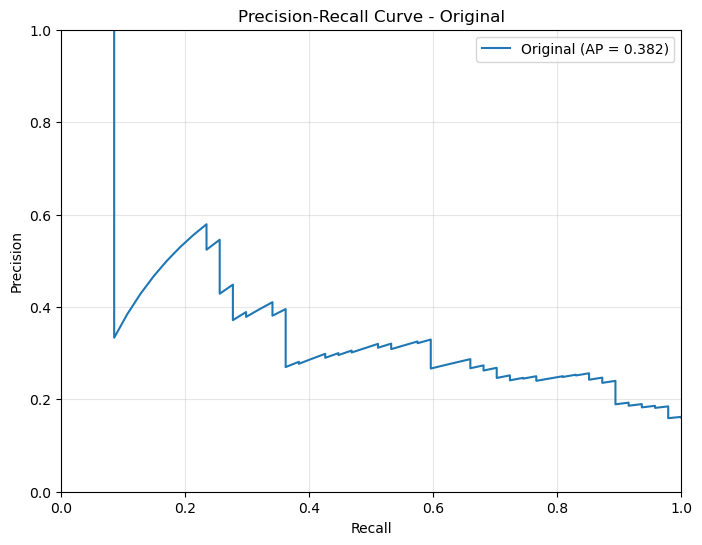

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



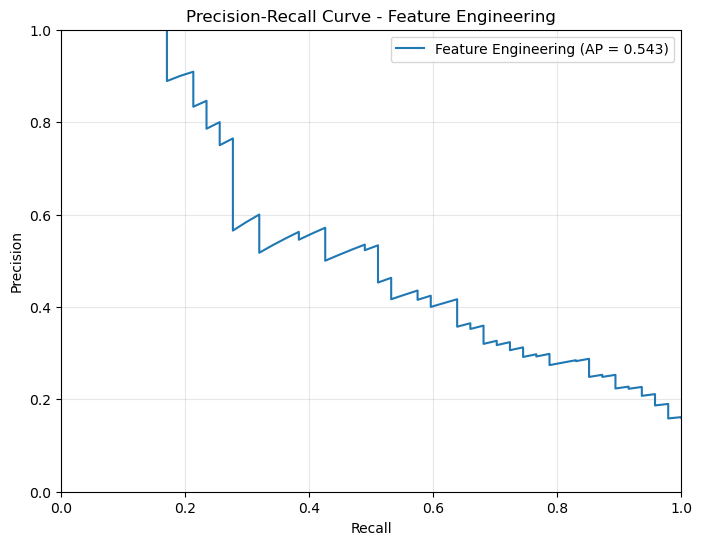

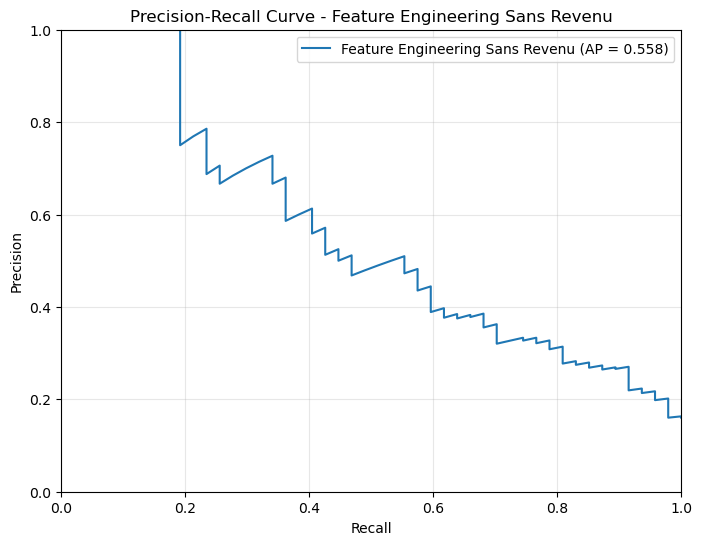

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



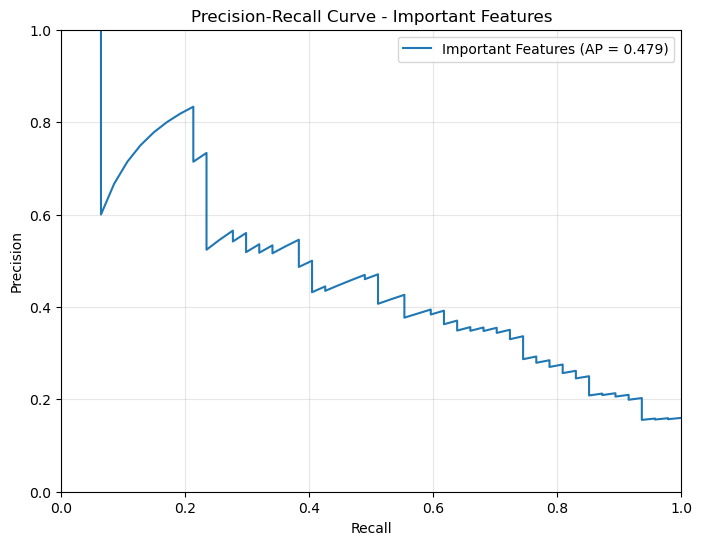

In [149]:
# Plot precision recall curve
ap_logistic_results = {}
for feature_name, df in feature_sets.items():

    logistic_pipeline, X_test, y_test, X_train, y_train = func_model_pipeline(
                    df,
                    target,
                    model_logistic,
                    binary_features,
                    num_method,
                    cat_method
                )
    
    logistic_pipeline.fit(X_train, y_train)
    ap_logistic_results[feature_name] = plot_precision_recall_curve(
        logistic_pipeline,
        X_test,
        y_test,
        feature_name,
        pos_label="Oui"
    )


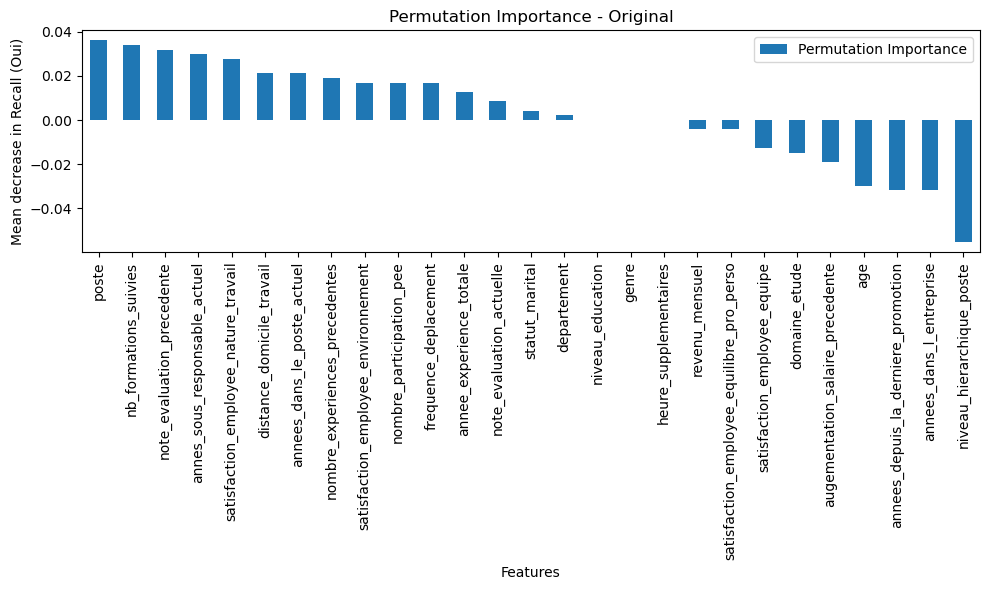

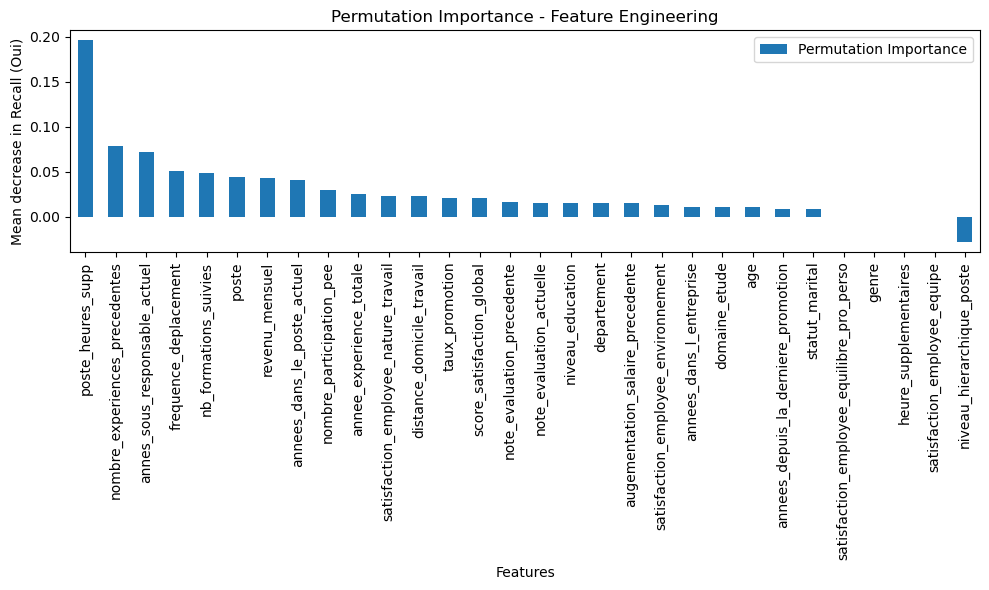

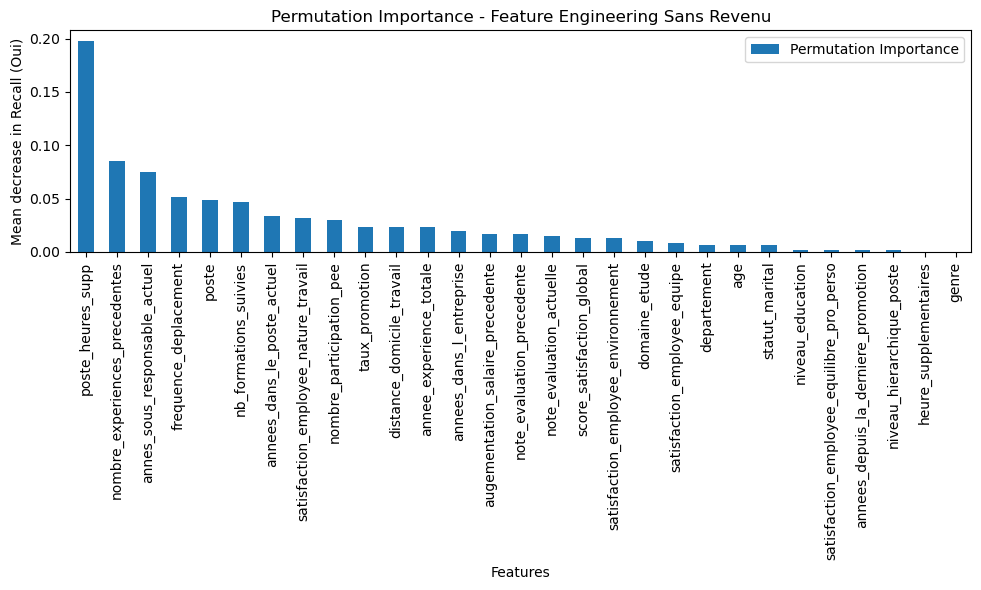

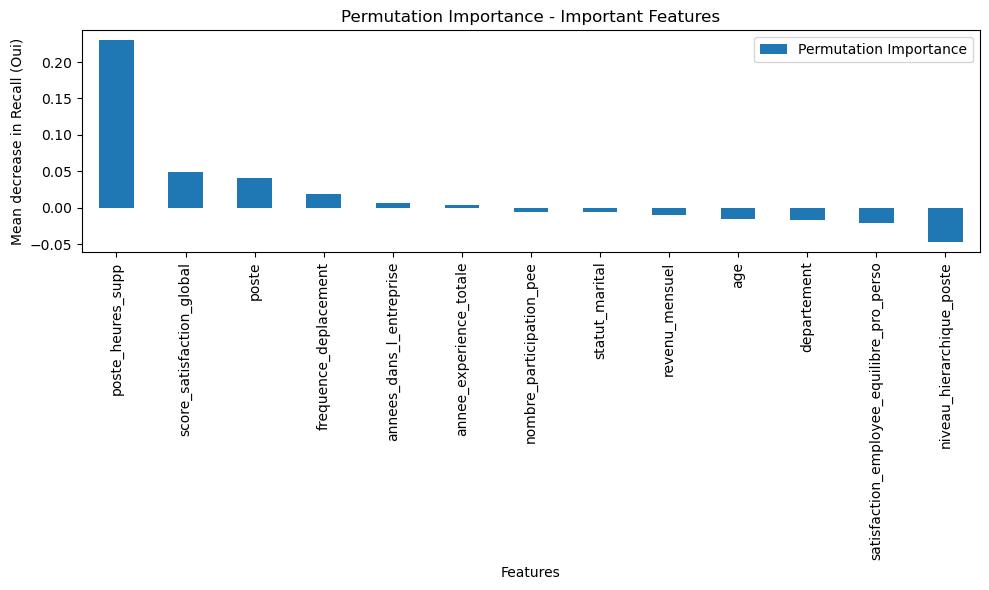

In [97]:
# Plot permutation importance
permutation_results = {}
for feature_name, df in feature_sets.items():
    logistic_pipeline, X_test, y_test, X_train, y_train = func_model_pipeline(
                df,
                target,
                model_logistic,
                binary_features,
                num_method,
                cat_method
            )
    logistic_pipeline.fit(X_train, y_train)
    permutation_results[feature_name] = func_get_permutation_importance(logistic_pipeline, X_test, y_test)
for feature_name, result in permutation_results.items():
    importance = result[["Feature","Permutation Importance"]]
    func_plot_permutation_importance(importance, feature_name)

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Original


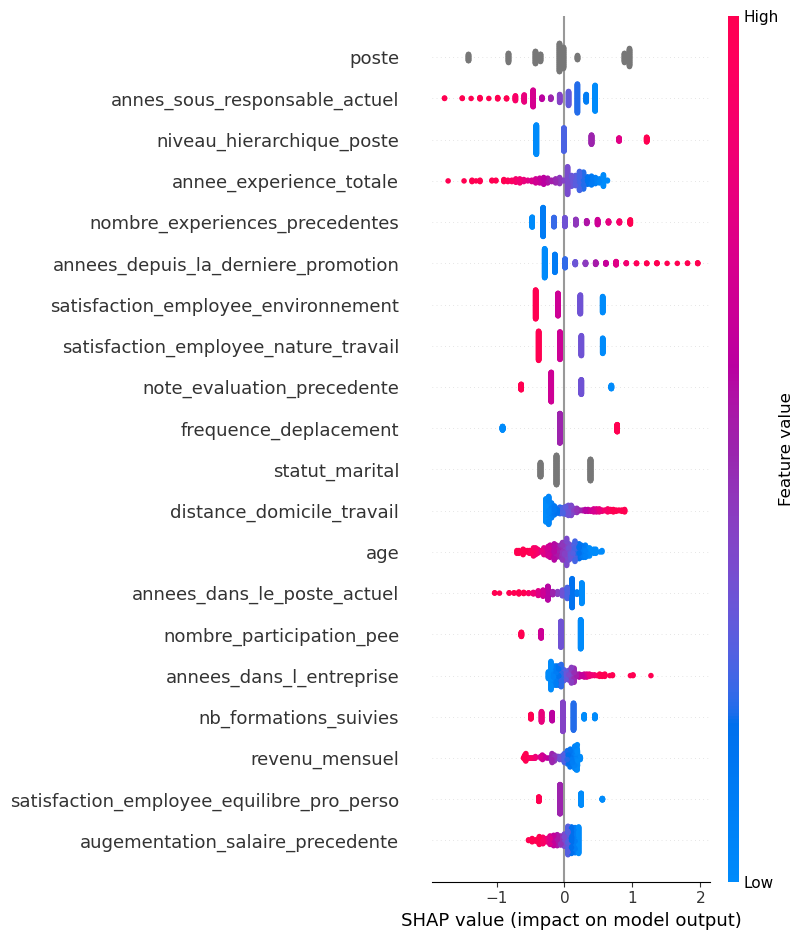

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Feature Engineering


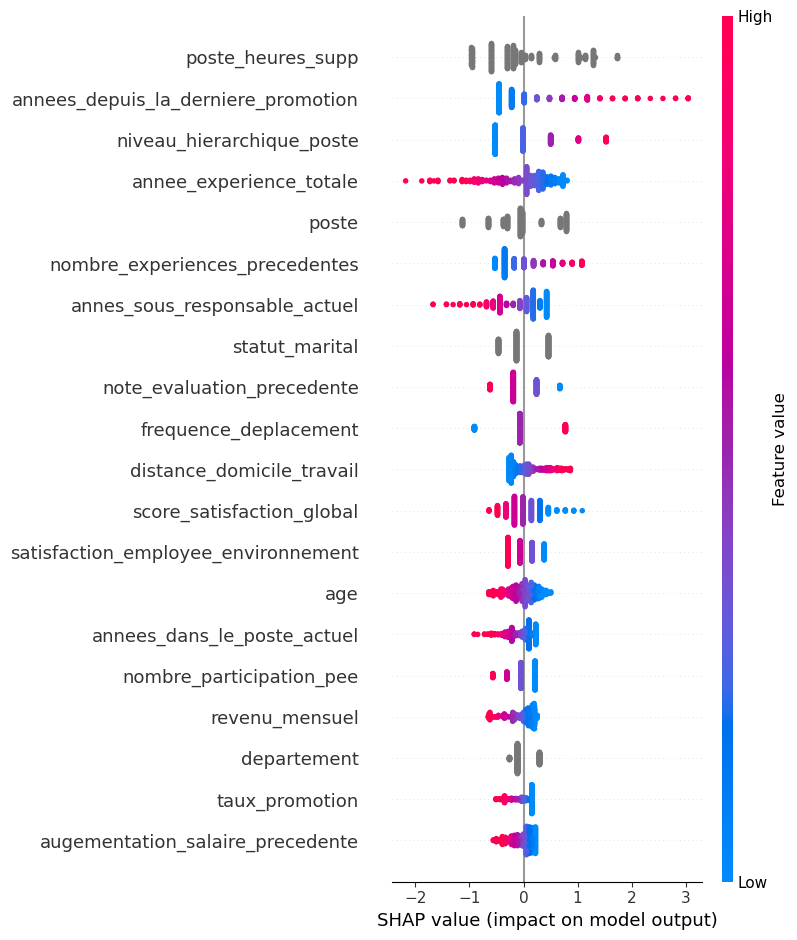

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Feature Engineering Sans Revenu


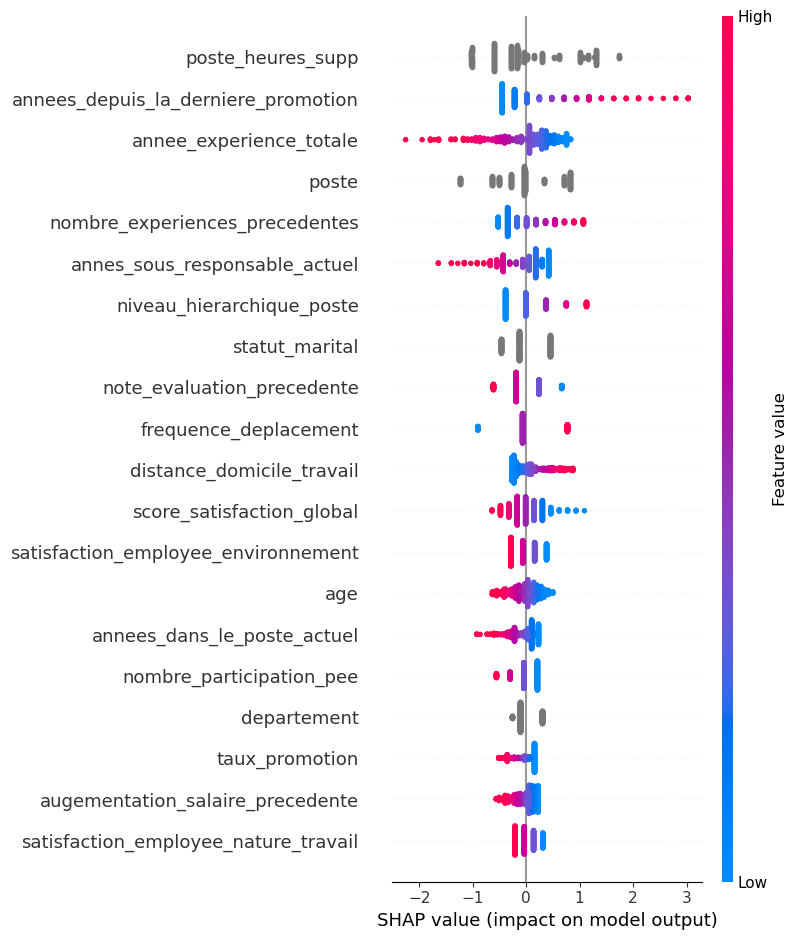

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Important Features


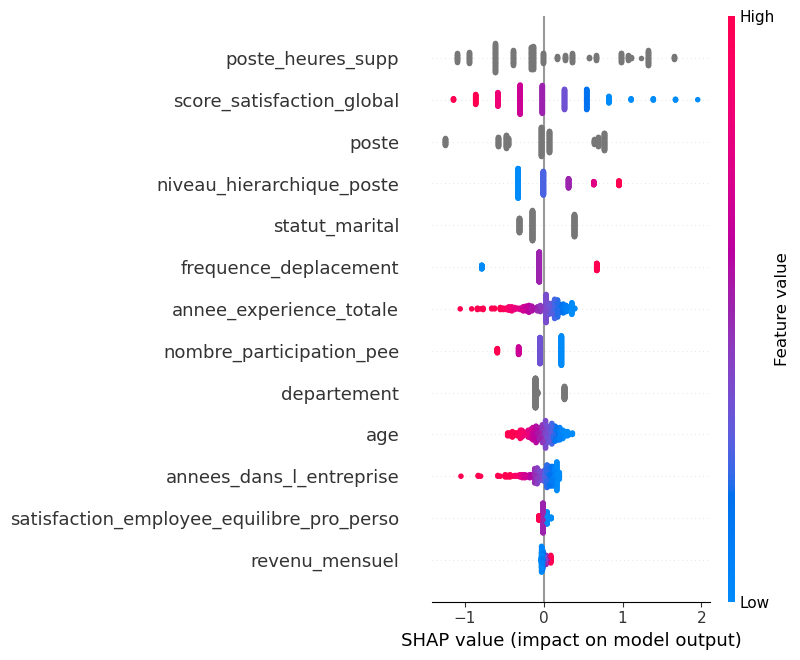

In [98]:
# plot shap
for feature_name, df in feature_sets.items():
    logistic_pipeline, X_test, y_test, X_train, y_train = func_model_pipeline(
                df,
                target,
                model_logistic,
                binary_features,
                num_method,
                cat_method
            )
    logistic_pipeline.fit(X_train, y_train)
    (
    shap_df,
    shap_values_original,
    feature_names,
    X_original,
    positive_index,
    explainer
    ) = func_shap_importance(
        model_pipeline=logistic_pipeline,
        is_linear=True,
        X_test=X_test,
        positive_class="Oui"
    )
    print("\nFeature Set:", feature_name)
    func_plot_shap(shap_values_original, X_original, feature_names)

In [148]:
# features importants
shap_results = {}
permutation_results = {}
tableau_features_importants = {}

for feature_name, df in feature_sets.items():

    # =====================================================
    # Training pipeline
    # =====================================================

    (
        logistic_pipeline,
        X_test,
        y_test,
        X_train,
        y_train
    ) = func_model_pipeline(
        df,
        target,
        model_logistic,
        binary_features,
        num_method,
        cat_method
    )

    logistic_pipeline.fit(
        X_train,
        y_train
    )

    # =====================================================
    # SHAP importance
    # =====================================================

    (
        shap_df,
        shap_values_positive,
        feature_names,
        X_transformed,
        positive_index,
        explainer
    ) = func_shap_importance(
        model_pipeline=logistic_pipeline,
        is_linear=True,
        X_test=X_test,
        positive_class="Oui",
    )
    shap_results[feature_name]=shap_df.copy()
    # =====================================================
    # Permutation importance
    # =====================================================

    permutation_df = (
        func_get_permutation_importance(
            logistic_pipeline,
            X_test,
            y_test
        )
    )
    permutation_results[feature_name]= permutation_df.copy()
    # =====================================================
    # Tableau final
    # =====================================================

    tableau_features_importants[feature_name] = (
    func_tableau_features_importants(
        shap_df,
        permutation_df
    )
)
for feature_name, df in tableau_features_importants.items():

    print("\n" + "=" * 70)
    print("FEATURE SET:", feature_name)
    print("=" * 70)

    display(df)

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.
C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the conver


FEATURE SET: Original


,Feature,Permutation Rank,SHAP Rank,Combined Rank
0,annes_sous_responsable_actuel,4,4,8
1,nombre_experiences_precedentes,4,5,9
2,poste,8,2,10
3,satisfaction_employee_nature_travail,2,10,12
4,annee_experience_totale,9,3,12
5,note_evaluation_precedente,1,12,13
6,statut_marital,3,13,16
7,satisfaction_employee_environnement,11,7,18
8,frequence_deplacement,12,9,21
9,revenu_mensuel,15,8,23



FEATURE SET: Feature Engineering


,Feature,Permutation Rank,SHAP Rank,Combined Rank
0,poste_heures_supp,1,2,3
1,nombre_experiences_precedentes,2,5,7
2,annee_experience_totale,6,3,9
3,annes_sous_responsable_actuel,3,8,11
4,revenu_mensuel,5,7,12
5,frequence_deplacement,4,11,15
6,statut_marital,11,9,20
7,satisfaction_employee_nature_travail,7,14,21
8,poste,17,6,23
9,note_evaluation_precedente,12,12,24



FEATURE SET: Feature Engineering Sans Revenu


,Feature,Permutation Rank,SHAP Rank,Combined Rank
0,poste_heures_supp,1,1,2
1,nombre_experiences_precedentes,2,5,7
2,annes_sous_responsable_actuel,3,6,9
3,poste,5,4,9
4,frequence_deplacement,4,11,15
5,annee_experience_totale,13,3,16
6,annees_dans_le_poste_actuel,7,14,21
7,satisfaction_employee_nature_travail,8,13,21
8,note_evaluation_precedente,13,10,23
9,distance_domicile_travail,12,12,24



FEATURE SET: Important Features


,Feature,Permutation Rank,SHAP Rank,Combined Rank
0,poste_heures_supp,1,1,2
1,poste,2,3,5
2,score_satisfaction_global,3,2,5
3,annee_experience_totale,4,7,11
4,frequence_deplacement,6,6,12
5,statut_marital,10,4,14
6,annees_dans_l_entreprise,4,11,15
7,nombre_participation_pee,7,9,16
8,departement,8,8,16
9,niveau_hierarchique_poste,13,5,18


C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Original


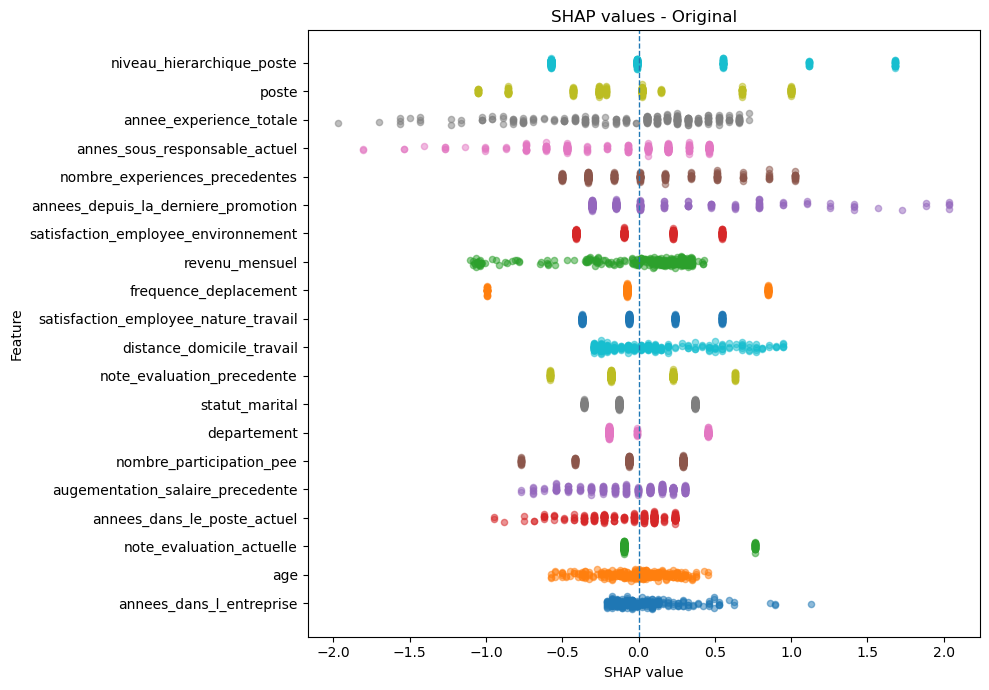

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Feature Engineering


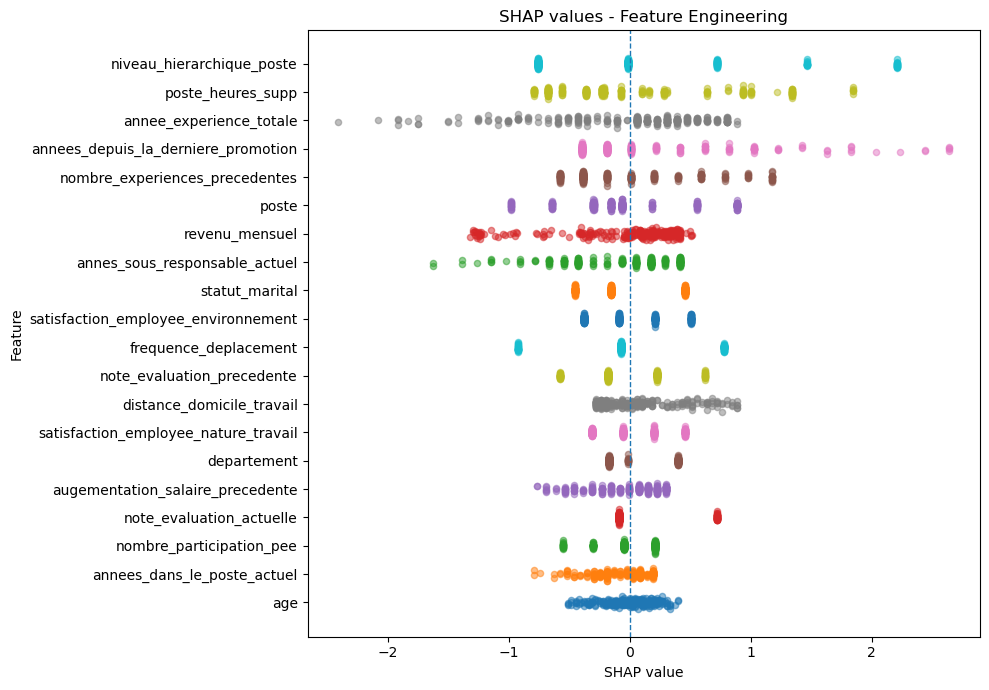

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Feature Engineering Sans Revenu


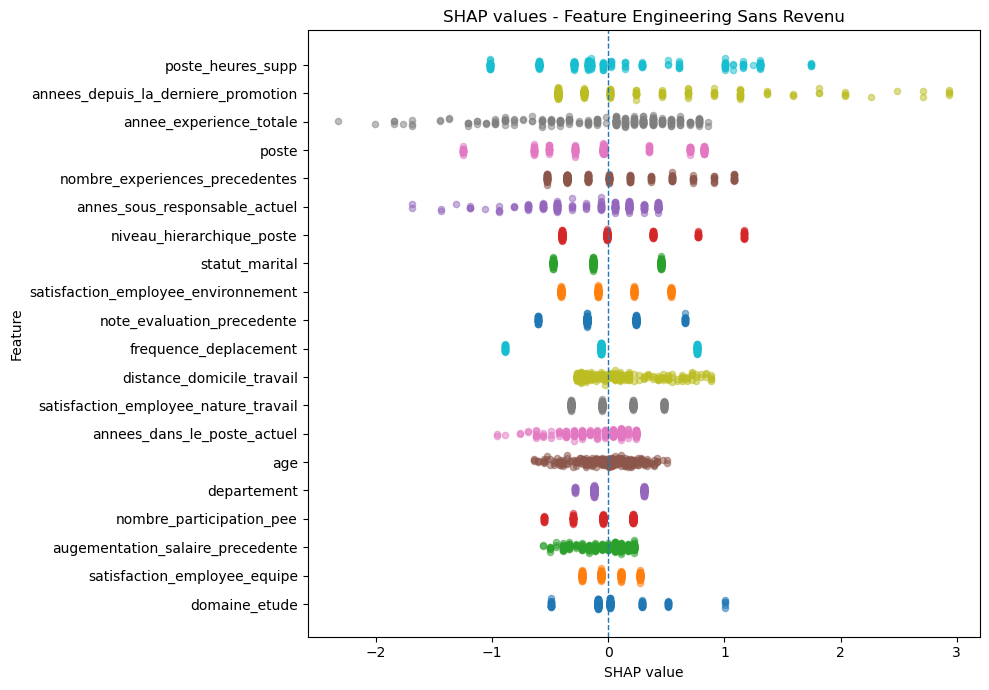

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Important Features


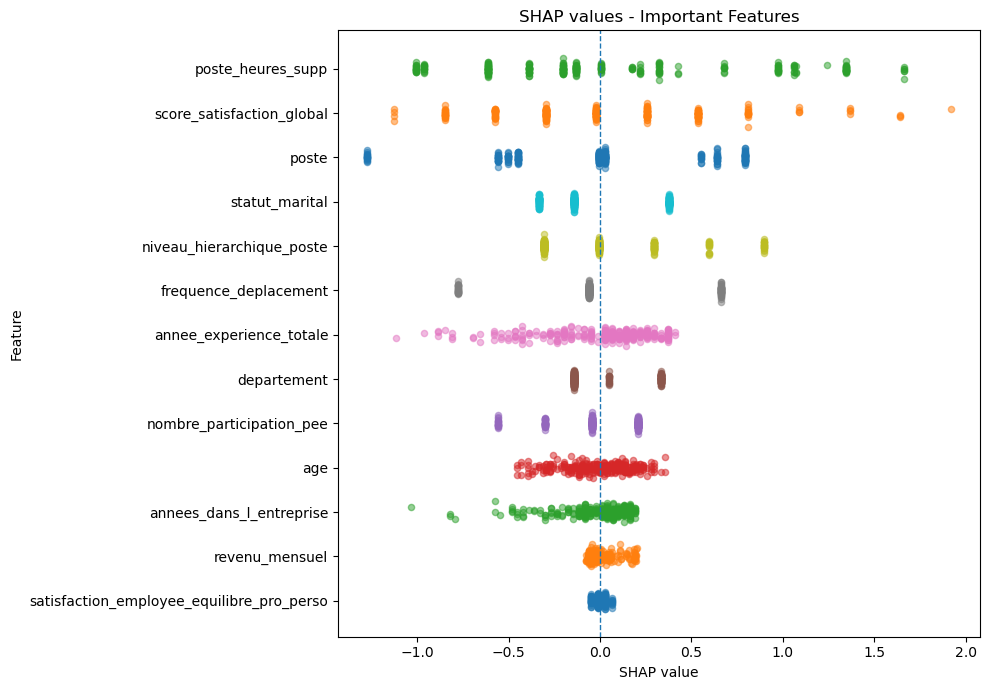

In [104]:
for feature_name, df in feature_sets.items():

    # =====================================================
    # Training pipeline
    # =====================================================

    (
        logistic_pipeline,
        X_test,
        y_test,
        X_train,
        y_train
    ) = func_model_pipeline(
        df,
        target,
        model_logistic,
        binary_features,
        num_method,
        cat_method
    )

    logistic_pipeline.fit(
        X_train,
        y_train
    )

    # =====================================================
    # SHAP importance
    # =====================================================

    (
        shap_df,
        shap_values_original,
        feature_names,
        X_transformed,
        positive_index,
        explainer
    ) = func_shap_importance(
        model_pipeline=logistic_pipeline,
        is_linear=True,
        X_test=X_test,
        positive_class="Oui",
    )

    print("\nFeature Set:", feature_name)
    
    func_shap_scatter(
        shap_values_original,
        feature_names,
        X_transformed,
        feature_name,
        max_display=20,
        figsize=(10, 7)
    )

In [108]:
for feature_name, df in feature_sets.items():

    # =====================================================
    # Training pipeline
    # =====================================================

    (
        logistic_pipeline,
        X_test,
        y_test,
        X_train,
        y_train
    ) = func_model_pipeline(
        df,
        target,
        model_logistic,
        binary_features,
        num_method,
        cat_method
    )

    logistic_pipeline.fit(
        X_train,
        y_train
    )
    y_pred = logistic_pipeline.predict(X_test)
    results = pd.DataFrame({
        "observation": np.arange(len(X_test)),
        "classe_reelle": y_test.values if hasattr(y_test, "values") else y_test,
        "classe_predite": y_pred
    })
    print("\nFeature Set:", feature_name)
    print(results.head(40))

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression




Feature Set: Original
    observation classe_reelle classe_predite
0             0           Non            Non
1             1           Non            Non
2             2           Non            Oui
3             3           Non            Non
4             4           Oui            Non
5             5           Non            Non
6             6           Non            Non
7             7           Non            Non
8             8           Non            Non
9             9           Non            Oui
10           10           Non            Non
11           11           Non            Oui
12           12           Non            Oui
13           13           Non            Oui
14           14           Non            Oui
15           15           Non            Oui
16           16           Non            Non
17           17           Non            Non
18           18           Non            Non
19           19           Non            Non
20           20           Oui   

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression




Feature Set: Feature Engineering
    observation classe_reelle classe_predite
0             0           Non            Non
1             1           Non            Non
2             2           Non            Non
3             3           Non            Non
4             4           Oui            Oui
5             5           Non            Oui
6             6           Non            Non
7             7           Non            Non
8             8           Non            Non
9             9           Non            Non
10           10           Non            Non
11           11           Non            Oui
12           12           Non            Oui
13           13           Non            Oui
14           14           Non            Oui
15           15           Non            Oui
16           16           Non            Non
17           17           Non            Non
18           18           Non            Oui
19           19           Non            Non
20           20      

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Original


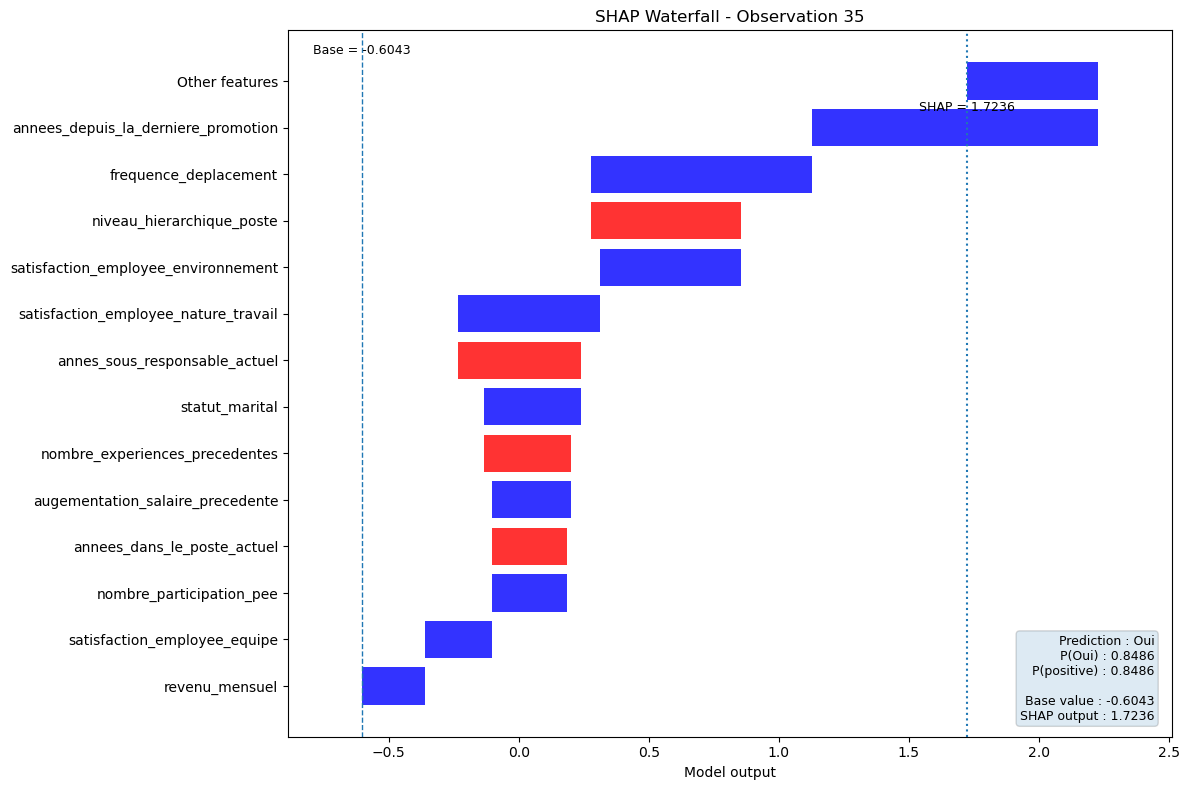

{'observation_index': 35, 'original_index': np.int64(514), 'employee_info': age                                                              33
genre                                                             1
revenu_mensuel                                                 3348
statut_marital                                          Célibataire
departement                                              Consulting
poste                                        Assistant de Direction
nombre_experiences_precedentes                                    1
annee_experience_totale                                          10
annees_dans_l_entreprise                                         10
annees_dans_le_poste_actuel                                       8
satisfaction_employee_environnement                               1
note_evaluation_precedente                                        3
niveau_hierarchique_poste                                         1
satisfaction_employee_nature_travail    

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Feature Engineering


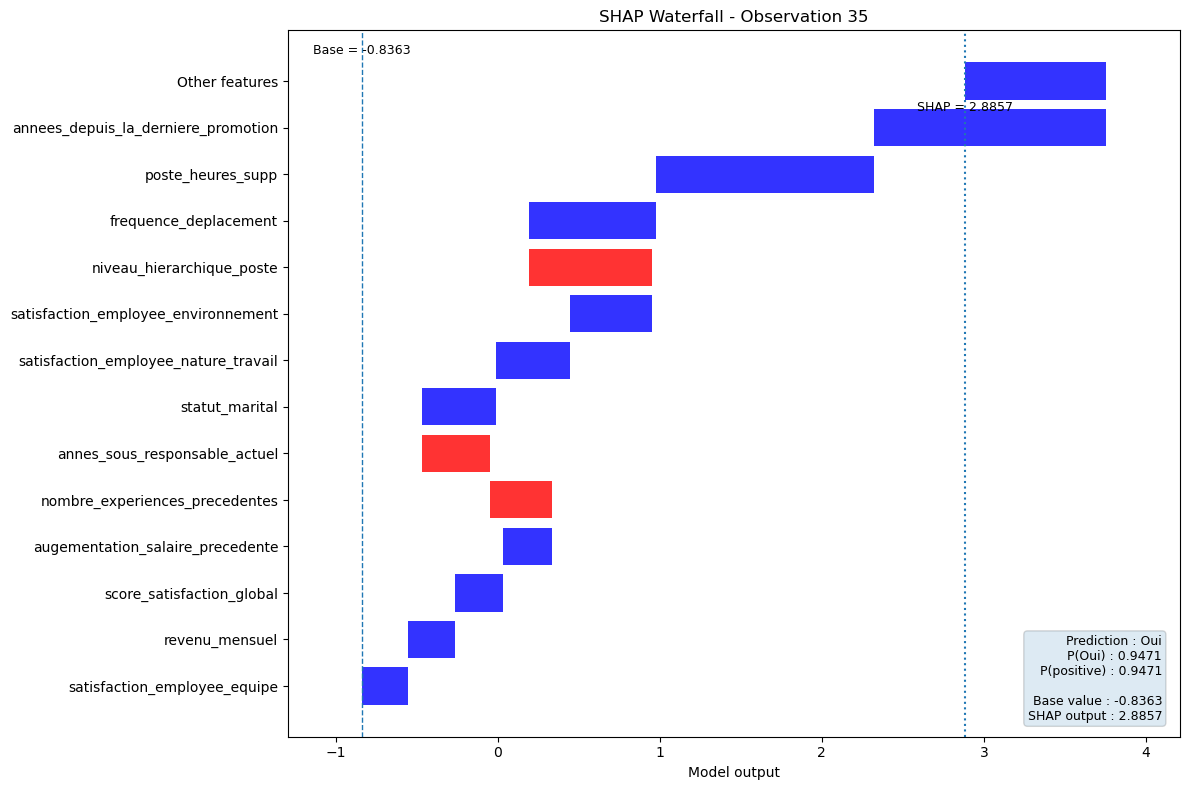

{'observation_index': 35, 'original_index': np.int64(514), 'employee_info': age                                                                33
genre                                                               1
revenu_mensuel                                                   3348
statut_marital                                            Célibataire
departement                                                Consulting
poste                                          Assistant de Direction
nombre_experiences_precedentes                                      1
annee_experience_totale                                            10
annees_dans_l_entreprise                                           10
annees_dans_le_poste_actuel                                         8
satisfaction_employee_environnement                                 1
note_evaluation_precedente                                          3
niveau_hierarchique_poste                                           1
satisfaction_e

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Feature Engineering Sans Revenu


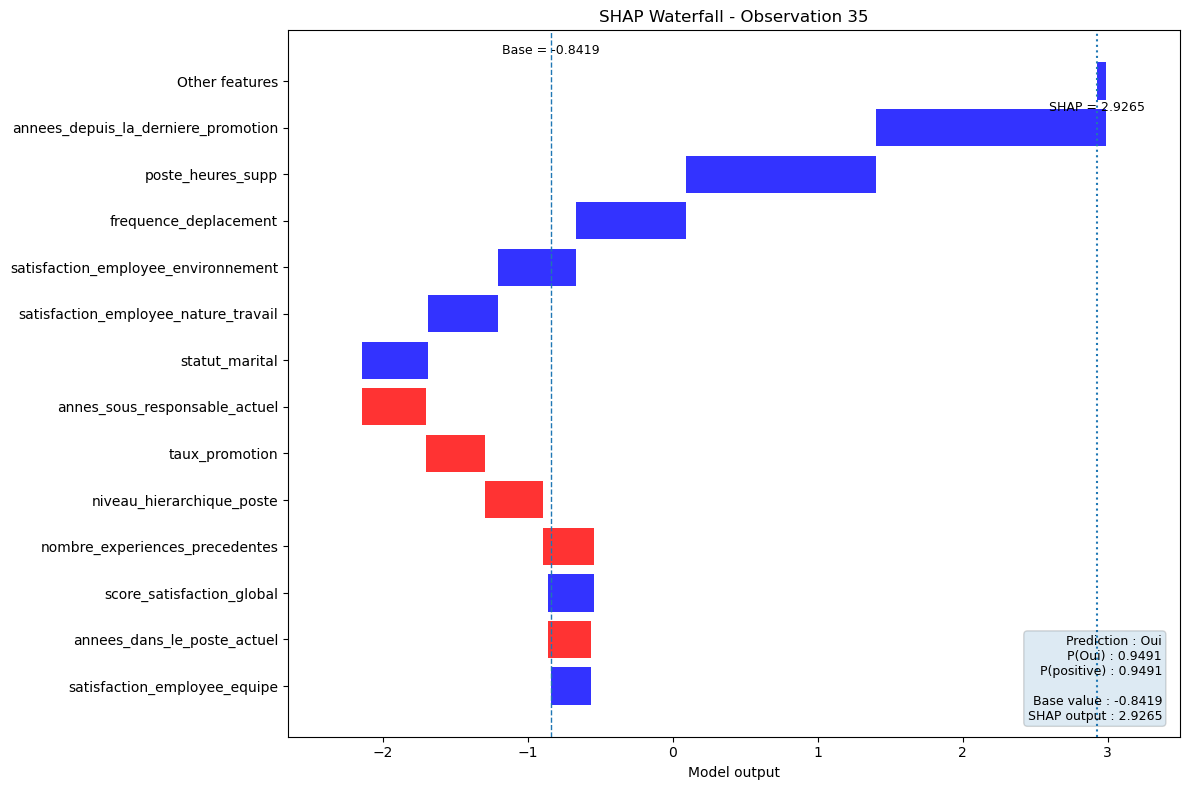

{'observation_index': 35, 'original_index': np.int64(514), 'employee_info': age                                                                33
genre                                                               1
statut_marital                                            Célibataire
departement                                                Consulting
poste                                          Assistant de Direction
nombre_experiences_precedentes                                      1
annee_experience_totale                                            10
annees_dans_l_entreprise                                           10
annees_dans_le_poste_actuel                                         8
satisfaction_employee_environnement                                 1
note_evaluation_precedente                                          3
niveau_hierarchique_poste                                           1
satisfaction_employee_nature_travail                                1
satisfaction_e

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Important Features


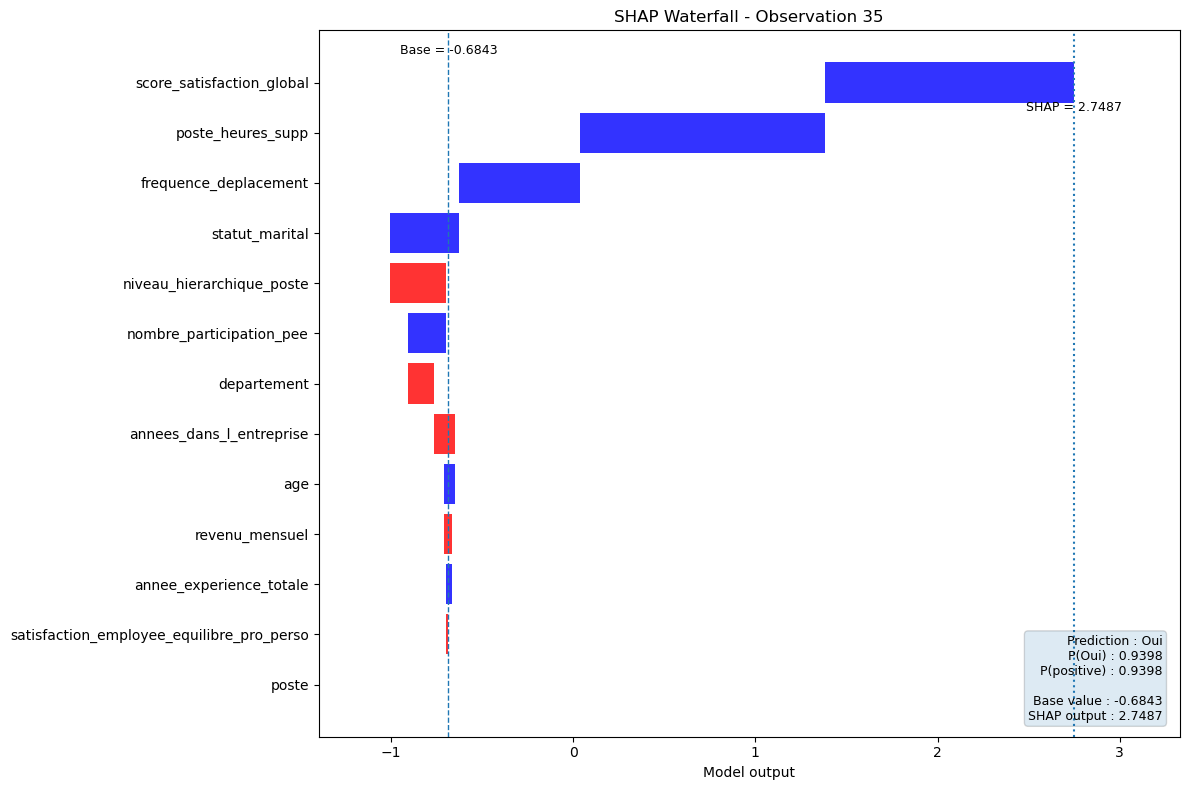

{'observation_index': 35, 'original_index': np.int64(514), 'employee_info': revenu_mensuel                                                   3348
annee_experience_totale                                            10
annees_dans_l_entreprise                                           10
age                                                                33
niveau_hierarchique_poste                                           1
nombre_participation_pee                                            0
poste_heures_supp                            Assistant de Direction_1
statut_marital                                            Célibataire
score_satisfaction_global                                         1.5
satisfaction_employee_equilibre_pro_perso                           3
departement                                                Consulting
frequence_deplacement                                               2
poste                                          Assistant de Direction
a_quitte_l_ent

In [147]:
# waterfall pour observation 35: Oui, Oui
for feature_name, df in feature_sets.items():

    # =====================================================
    # Training pipeline
    # =====================================================

    (
        logistic_pipeline,
        X_test,
        y_test,
        X_train,
        y_train
    ) = func_model_pipeline(
        df,
        target,
        model_logistic,
        binary_features,
        num_method,
        cat_method
    )

    logistic_pipeline.fit(
        X_train,
        y_train
    )

    # =====================================================
    # SHAP importance
    # =====================================================

    (
        shap_df,
        shap_values_original,
        original_features,
        X_original,
        positive_index,
        explainer
    ) = func_shap_importance(
        model_pipeline=logistic_pipeline,
        is_linear=True,
        X_test=X_test,
        positive_class="Oui",
    )

    print("\nFeature Set:", feature_name)
    result, prediction_info = func_shap_waterfall(
        shap_values_original=shap_values_original,
        original_features=original_features,
        X_test=X_original,
        explainer=explainer,
        model_pipeline=logistic_pipeline,
        positive_index=positive_index,
        observation_index=35,
        max_display=13,
        df=df
    )
    print(prediction_info)

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Original


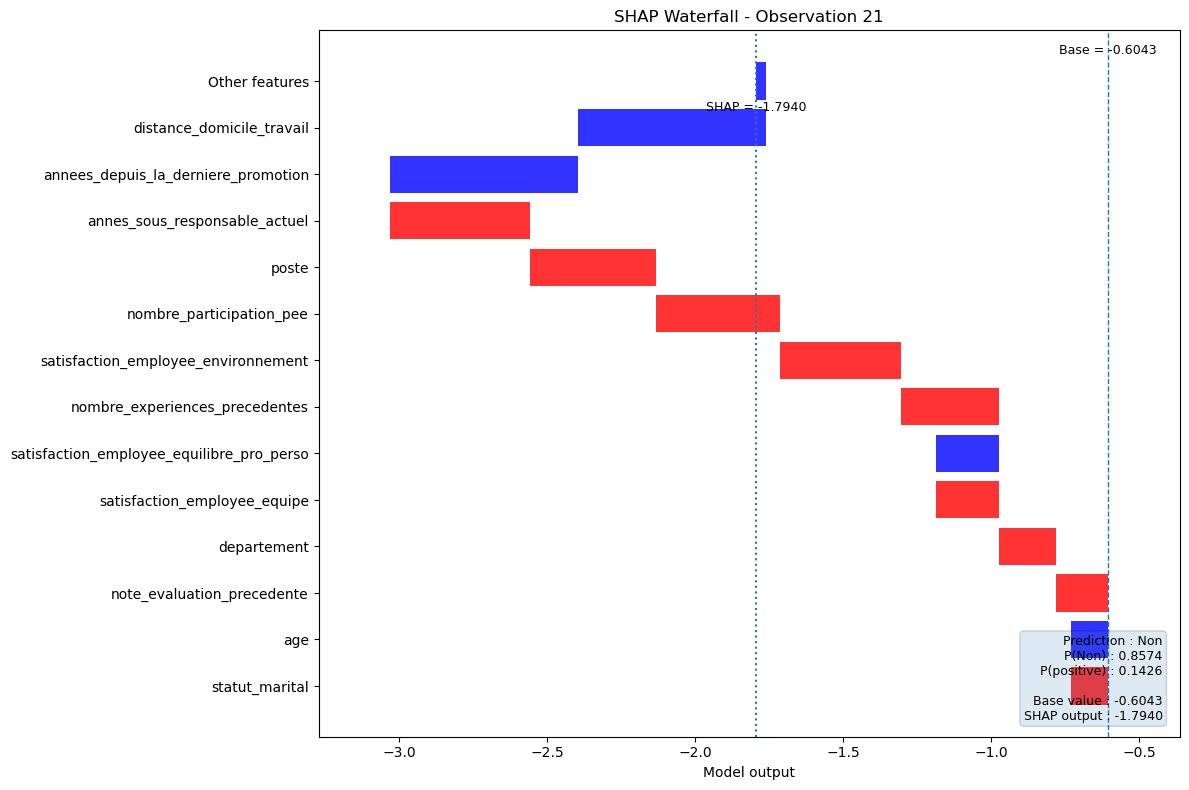

{'observation_index': 21, 'original_index': np.int64(985), 'employee_info': age                                                               31
genre                                                              1
revenu_mensuel                                                  6179
statut_marital                                              Marié(e)
departement                                               Consulting
poste                                                      Tech Lead
nombre_experiences_precedentes                                     1
annee_experience_totale                                           10
annees_dans_l_entreprise                                          10
annees_dans_le_poste_actuel                                        2
satisfaction_employee_environnement                                4
note_evaluation_precedente                                         3
niveau_hierarchique_poste                                          2
satisfaction_employee_natur

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Feature Engineering


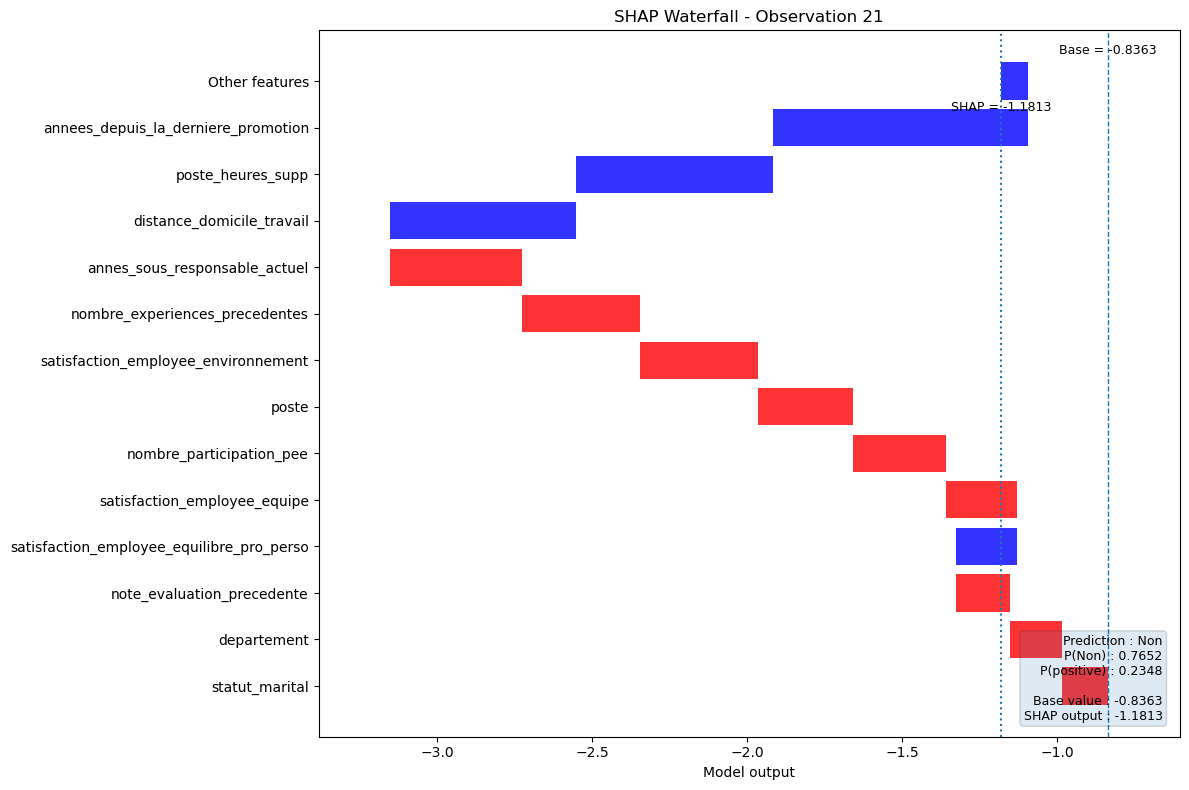

{'observation_index': 21, 'original_index': np.int64(985), 'employee_info': age                                                               31
genre                                                              1
revenu_mensuel                                                  6179
statut_marital                                              Marié(e)
departement                                               Consulting
poste                                                      Tech Lead
nombre_experiences_precedentes                                     1
annee_experience_totale                                           10
annees_dans_l_entreprise                                          10
annees_dans_le_poste_actuel                                        2
satisfaction_employee_environnement                                4
note_evaluation_precedente                                         3
niveau_hierarchique_poste                                          2
satisfaction_employee_natur

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Feature Engineering Sans Revenu


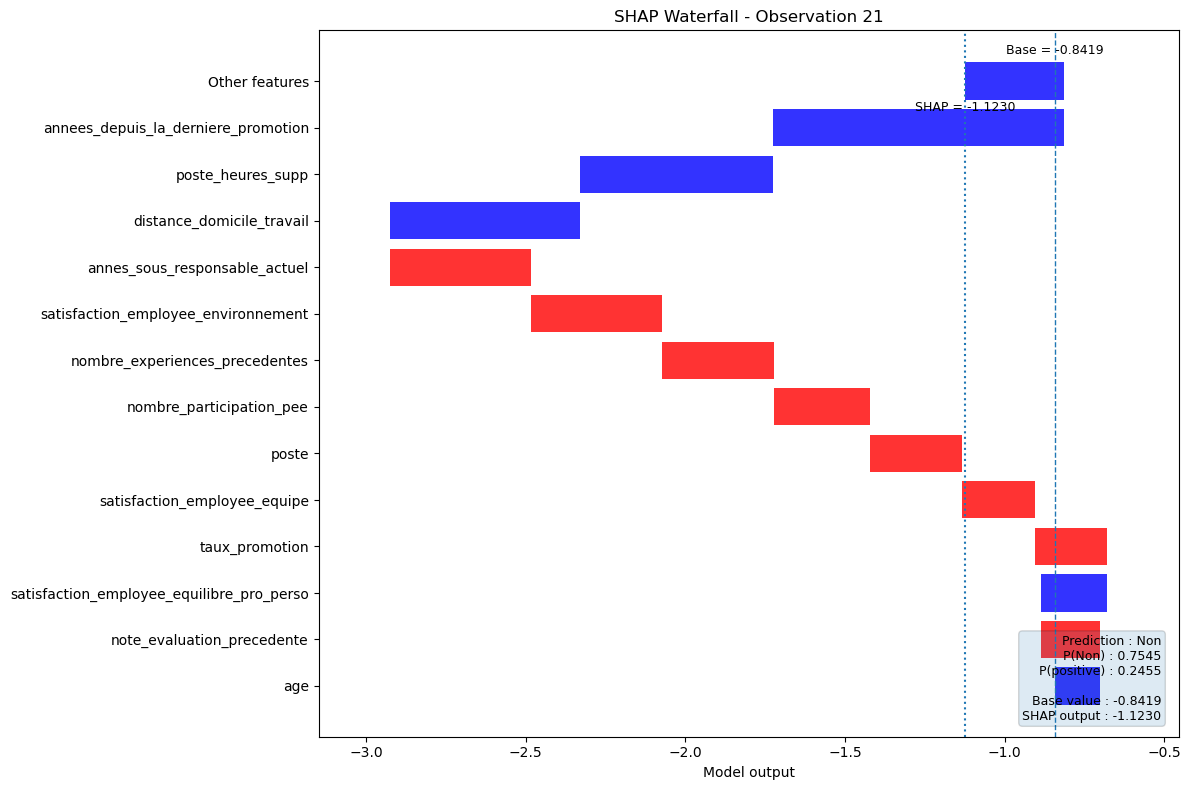

{'observation_index': 21, 'original_index': np.int64(985), 'employee_info': age                                                               31
genre                                                              1
statut_marital                                              Marié(e)
departement                                               Consulting
poste                                                      Tech Lead
nombre_experiences_precedentes                                     1
annee_experience_totale                                           10
annees_dans_l_entreprise                                          10
annees_dans_le_poste_actuel                                        2
satisfaction_employee_environnement                                4
note_evaluation_precedente                                         3
niveau_hierarchique_poste                                          2
satisfaction_employee_nature_travail                               3
satisfaction_employee_equip

C:\Users\vtmnh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Background dataset has 294 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=294 when initializing the masker.



Feature Set: Important Features


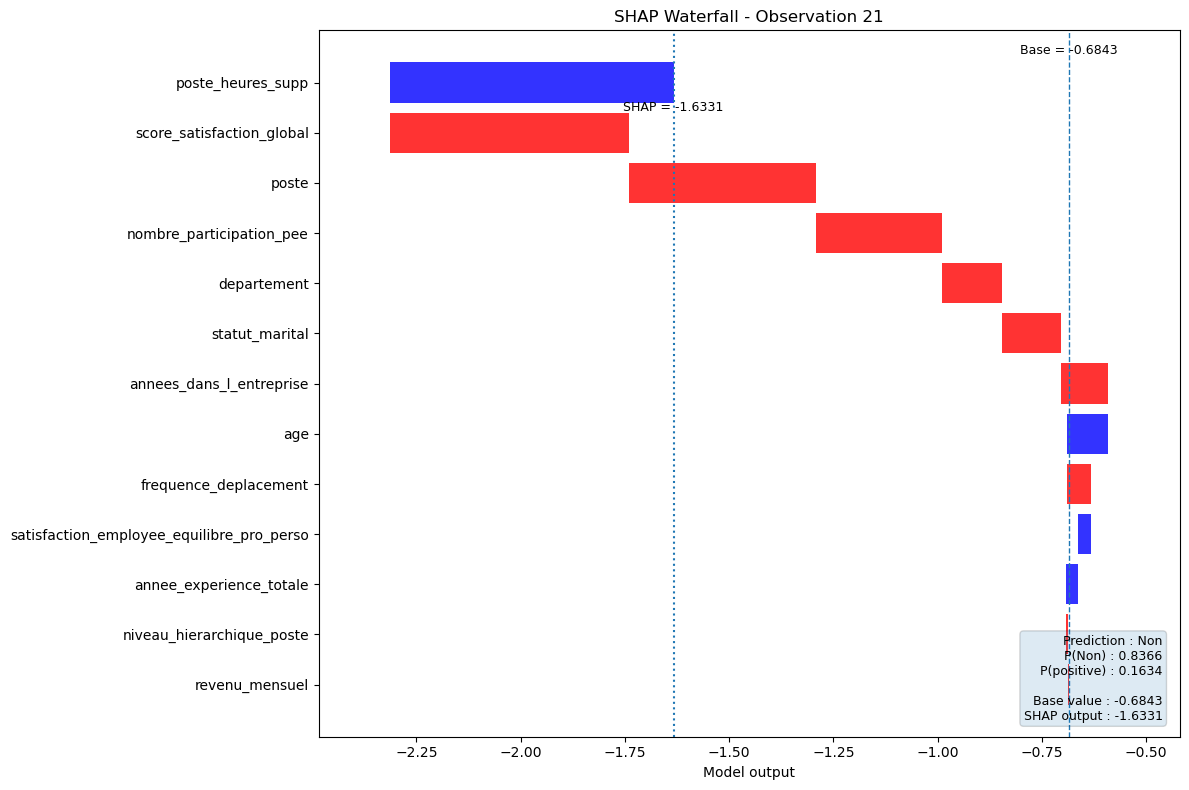

{'observation_index': 21, 'original_index': np.int64(985), 'employee_info': revenu_mensuel                                      6179
annee_experience_totale                               10
annees_dans_l_entreprise                              10
age                                                   31
niveau_hierarchique_poste                              2
nombre_participation_pee                               2
poste_heures_supp                            Tech Lead_1
statut_marital                                  Marié(e)
score_satisfaction_global                           3.25
satisfaction_employee_equilibre_pro_perso              2
departement                                   Consulting
frequence_deplacement                                  1
poste                                          Tech Lead
a_quitte_l_entreprise                                Oui
Name: 985, dtype: object, 'predicted_class': 'Non', 'positive_probability': np.float64(0.1634024167027192), 'base_value': np.f

In [146]:
# waterfall pour observation 21: Oui, Non
for feature_name, df in feature_sets.items():

    # =====================================================
    # Training pipeline
    # =====================================================

    (
        logistic_pipeline,
        X_test,
        y_test,
        X_train,
        y_train
    ) = func_model_pipeline(
        df,
        target,
        model_logistic,
        binary_features,
        num_method,
        cat_method
    )

    logistic_pipeline.fit(
        X_train,
        y_train
    )

    # =====================================================
    # SHAP importance
    # =====================================================

    (
        shap_df,
        shap_values_original,
        original_features,
        X_original,
        positive_index,
        explainer
    ) = func_shap_importance(
        model_pipeline=logistic_pipeline,
        is_linear=True,
        X_test=X_test,
        positive_class="Oui",
    )

    print("\nFeature Set:", feature_name)
    result, prediction_info = func_shap_waterfall(
        shap_values_original=shap_values_original,
        original_features=original_features,
        X_test=X_original,
        explainer=explainer,
        model_pipeline=logistic_pipeline,
        positive_index=positive_index,
        observation_index=21,
        max_display=13,
        df=df
    )
    print(prediction_info)

<h1> Random Forest</h1>

<h2>5.1 Random forest classique balances</h2>

In [128]:
num_method = "passthrough"
cat_method = OneHotEncoder(handle_unknown="ignore")
model_random_forest = RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42
            )
result_random_forest = func_evaluate_model(model_random_forest, feature_sets, target, binary_features, num_method, cat_method)
print(result_random_forest)

                       Feature Set  Train_Accuracy  Train_Precision  \
0                         Original             1.0              1.0   
1              Feature Engineering             1.0              1.0   
2  Feature Engineering Sans Revenu             1.0              1.0   
3               Important Features             1.0              1.0   

   Train_Recall  Train_F1  Test_Accuracy  Test_Precision  Test_Recall  \
0           1.0       1.0       0.833333        0.400000     0.085106   
1           1.0       1.0       0.836735        0.428571     0.063830   
2           1.0       1.0       0.840136        0.500000     0.085106   
3           1.0       1.0       0.853741        0.642857     0.191489   

    Test_F1  Train_F1_Oui  Test_F1_Oui  Train_Recall_Oui  Test_Recall_Oui  \
0  0.140351           1.0     0.140351               1.0         0.085106   
1  0.111111           1.0     0.111111               1.0         0.063830   
2  0.145455           1.0     0.145455         

<h2>5.2 Utilise gridSearchCv pour choisir parametre max-depth</h2>

In [131]:
def gridsearch_random_forest(
    feature_sets,
    target,
    binary_features,
    num_method,
    cat_method
):
    best_models = []

    parameters = {
        "model__max_depth": np.arange(2, 30, 2)
    }

    recall_oui = make_scorer(
        recall_score,
        pos_label="Oui",
        zero_division=0
    )

    for feature_name, df in feature_sets.items():

        rf_pipeline, X_test, y_test, X_train, y_train = func_model_pipeline(
                df,
                target,
                model_random_forest,
                binary_features,
                num_method,
                cat_method
            )
        
        # GridSearch
        clf = GridSearchCV(
            rf_pipeline,
            param_grid=parameters,
            cv=5,
            scoring=recall_oui,
            n_jobs=-1
        )

        clf.fit(X_train, y_train)

        # Sauvegarder les résultats
        best_models.append({
            "Feature Set": feature_name,
            "Best Parameters": clf.best_params_,
            "Best Estimator": clf.best_estimator_,
            "X_train": X_train,
            "y_train": y_train,
            "X_test": X_test,
            "y_test": y_test
        })

    return best_models

In [133]:
best_models = gridsearch_random_forest(
    feature_sets,
    target,
    binary_features,
    num_method,
    cat_method
)

results = []

for item in best_models:

    result = scoring_model(
        item["Best Estimator"],
        item["X_train"],
        item["y_train"],
        item["X_test"],
        item["y_test"],
        item["Feature Set"]
    )

    result["Best max_depth"] = item[
        "Best Parameters"
    ]["model__max_depth"]

    results.append(result)

results_df = pd.DataFrame(results)

print(results_df)

                       Feature Set  Train_Accuracy  Train_Precision  \
0                         Original        0.789966         0.400000   
1              Feature Engineering        0.795068         0.412969   
2  Feature Engineering Sans Revenu        0.802721         0.427586   
3               Important Features        0.834184         0.490566   

   Train_Recall  Train_F1  Test_Accuracy  Test_Precision  Test_Recall  \
0      0.600000  0.480000       0.724490        0.287500     0.489362   
1      0.636842  0.501035       0.765306        0.358974     0.595745   
2      0.652632  0.516667       0.744898        0.315789     0.510638   
3      0.684211  0.571429       0.778912        0.359375     0.489362   

    Test_F1  Train_F1_Oui  Test_F1_Oui  Train_Recall_Oui  Test_Recall_Oui  \
0  0.362205      0.480000     0.362205          0.600000         0.489362   
1  0.448000      0.501035     0.448000          0.636842         0.595745   
2  0.390244      0.516667     0.390244         

<h2>5.3 Plot precission recall curve</h2>

In [ ]:
ap_best_models = {}

for result in best_models:

    feature_name = result["Feature Set"]
    model = result["Best Estimator"]
    X_test = result["X_test"]
    y_test = result["y_test"]

    ap = plot_precision_recall_curve(
        model=model,
        X_test=X_test,
        y_test=y_test,
        model_name=feature_name,
        pos_label="Oui"
    )

    ap_best_models[feature_name] = ap

<h2>5.4 Permutation importance</h2>

In [99]:
for result in best_models:

    feature_name = result["Feature Set"]
    model_pipeline = result["Best Estimator"]
    X_test = result["X_test"]
    y_test = result["y_test"]
    permutation_results[feature_name] = func_get_permutation_importance(model_pipeline, X_test, y_test)
    
for feature_name, result in permutation_results.items():
    importance = result[["Feature","Permutation Importance"]]
    func_plot_permutation_importance(importance, feature_name)


NameError: name 'best_models' is not defined

In [ ]:
for item in best_models:

    model = item["Best Estimator"]
    X_test = item["X_test"]
    feature_name = item["Feature Set"]

    print("\nFeature Set:", feature_name)

    (
        shap_df,
        shap_values_positive,
        feature_names,
        X_original,
        positive_index,
        explainer
    ) = func_shap_importance(
        model_pipeline=model,
        is_linear=False,
        X_test=X_test,
        positive_class="Oui",
        pipeline=True
    )

    func_plot_shap(
        shap_values_positive,
        X_original,
        feature_names
    )

In [ ]:
# features importants
shap_results = {}
permutation_results = {}
tableau_features_importants = {}

for item in best_models:

    model = item["Best Estimator"]
    X_test = item["X_test"]
    y_test = item["y_test"]
    feature_name = item["Feature Set"]

    (
        shap_df,
        shap_values_positive,
        feature_names,
        X_original,
        positive_index,
        explainer
    ) = func_shap_importance(
        model_pipeline=model,
        is_linear=False,
        X_test=X_test,
        positive_class="Oui",
    )
    shap_results[feature_name]=shap_df.copy()
    # =====================================================
    # Permutation importance
    # =====================================================

    permutation_df = func_get_permutation_importance(model, X_test, y_test)
    permutation_results[feature_name]= permutation_df.copy()
    # =====================================================
    # Tableau final
    # =====================================================

    tableau_features_importants[feature_name] = (
        func_tableau_features_importants(
            shap_df.copy(),
            permutation_df.copy(),
        )
    )
for feature_name, df in tableau_features_importants.items():

    print("\n" + "=" * 70)
    print("FEATURE SET:", feature_name)
    print("=" * 70)

    display(df)

In [ ]:
for item in best_models:

    model = item["Best Estimator"]
    X_test = item["X_test"]

    (
        shap_df,
        shap_values_original,
        feature_names,
        X_original,
        positive_index,
        explainer
    ) = func_shap_importance(
        model_pipeline=model,
        is_linear=False,
        X_test=X_test,
        positive_class="Oui",
    )
for feature_name, df in feature_sets.items():
    print("\nFeature Set:", feature_name)
    
    func_shap_scatter(
        shap_values_original,
        feature_names,
        X_original,
        feature_name,
        max_display=20,
        figsize=(10, 7)
    )

In [ ]:
for item in best_models:

    model = item["Best Estimator"]
    X_test = item["X_test"]
    y_test = item["y_test"]
    feature_name = item["Feature Set"]
    y_pred = model.predict(X_test)
    results = pd.DataFrame({
        "observation": np.arange(len(X_test)),
        "classe_reelle": y_test.values if hasattr(y_test, "values") else y_test,
        "classe_predite": y_pred
    })
    print("\nFeature Set:", feature_name)
    print(results.head(20))

In [ ]:
# waterfall pour observation 1: non, non
for item in best_models:
    model = item["Best Estimator"]
    X_test = item["X_test"]
    (
        shap_df,
        shap_values_original,
        original_features,
        X_original,
        positive_index,
        explainer
    ) = func_shap_importance(
        model_pipeline=model,
        is_linear=False,
        X_test=X_test,
        positive_class="Oui",
    )
for feature_name, df in feature_sets.items():
    print("\nFeature Set:", feature_name)
    
    result, prediction_info = func_shap_waterfall(
        shap_values_original=shap_values_original,
        original_features=original_features,
        X_test=X_original,
        explainer=explainer,
        model_pipeline=model,
        positive_index=positive_index,
        observation_index=1,
        max_display=13
    )
    print(prediction_info)

In [ ]:
# waterfall pour observation 0: non, oui
for item in best_models:
    model = item["Best Estimator"]
    X_test = item["X_test"]
    (
        shap_df,
        shap_values_original,
        original_features,
        X_original,
        positive_index,
        explainer
    ) = func_shap_importance(
        model_pipeline=model,
        is_linear=False,
        X_test=X_test,
        positive_class="Oui",
    )
for feature_name, df in feature_sets.items():
    print("\nFeature Set:", feature_name)
    
    result, prediction_info = func_shap_waterfall(
        shap_values_original=shap_values_original,
        original_features=original_features,
        X_test=X_original,
        explainer=explainer,
        model_pipeline=model,
        positive_index=positive_index,
        observation_index=0,
        max_display=13
    )
    print(prediction_info)

<h1>Comparison</h1>

In [ ]:
results = []

models_predictions = {
    "Dummy": (
        y_train_pred_dummy,
        y_test_pred_dummy
    ),
    "Logistic Regression": (
        y_train_pred_linear,
        y_test_pred_linear
    ),
    "Random Forest Depth Optimal": (
        y_train_pred_rf_balanced_bestDepth,
        y_test_pred_rf_balanced_bestDepth
    )
}

for name, (train_pred, test_pred) in models_predictions.items():
    